# Rotten Tomatoes Tomatometer Nowcasting Model

**Goal:** Given partial incoming critic reviews for a movie, estimate the expected final Tomatometer  
score (% Fresh) with uncertainty via Monte Carlo simulation.

**Approach:**  
1. **Selection model** — predict which critics will review a movie  
2. **Outcome model** — predict whether a review will be Fresh (given review happens)  
3. **Combine** via Monte Carlo for live nowcasting with uncertainty intervals

## 0. Configuration & Settings

In [1]:
# ============================================================
# CONFIGURATION — edit these before running
# ============================================================

CSV_PATH = "rotten_tomatoes_critic_reviews.csv"
IMDB_GENRES_PATH = "imdb_genres.csv"  # from hf://datasets/jquigl/imdb-genres

# Column name mapping
COLUMN_MAP = {
    "movie_id":        "rotten_tomatoes_link",
    "critic_name":     "critic_name",
    "outlet":          "publisher_name",
    "review_date":     "review_date",
    "review_type":     "review_type",
    "is_fresh":        None,
    "review_score":    "review_score",
    "is_top_critic":   "top_critic",
    "movie_genres":    None,
    "wide_release_date": None,
    "runtime":         None,
    "mpaa_rating":     None,
    "studio":          None,
    "director":        None,
    "cast":            None,
}

# Modeling parameters
NEGATIVE_RATIO = 8
MIN_REVIEWS_PER_MOVIE = 20
MIN_REVIEWS_PER_CRITIC = 5
CUTOFF_DATE = "2019-01-01"
N_SIMS = 10_000
THRESHOLDS = [0.60, 0.70, 0.80, 0.90]
N_LATENT_GENRES = 15         # NMF components (supplement for movies without IMDB match)
RANDOM_SEED = 42

SELECTION_CHECKPOINTS = [5, 10, 25]
BACKTEST_CHECKPOINTS = [5, 10, 25, 50]
RECENT_WINDOWS_DAYS = [7, 30, 90]
MAX_CRITICS_UNIVERSE = 3000

# Local runtime controls — caps to keep laptop execution feasible
MAX_SELECTION_TRAIN_MOVIES = 2500
MAX_SELECTION_VAL_MOVIES = 600
MAX_OUTCOME_TRAIN_MOVIES = 3500
MAX_OUTCOME_VAL_MOVIES = 700
PROGRESS_EVERY_MOVIES = 100
MAX_SELECTION_TRAIN_ROWS = 1_500_000
MAX_SELECTION_VAL_ROWS = 450_000
MAX_OUTCOME_TRAIN_ROWS = 500_000
MAX_OUTCOME_VAL_ROWS = 200_000
MAX_BACKTEST_MOVIES = 100

## 1. Imports & Data Loading

In [2]:
import numpy, scipy, sklearn
print("numpy", numpy.__version__)
print("scipy", scipy.__version__)
print("sklearn", sklearn.__version__)

numpy 2.2.6
scipy 1.15.2
sklearn 1.7.2


In [3]:
import warnings
warnings.filterwarnings("ignore")

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
from collections import defaultdict
from scipy.sparse import csr_matrix

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import (
    roc_auc_score, log_loss, brier_score_loss,
    mean_absolute_error, mean_squared_error
)
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import NMF

try:
    import lightgbm as lgb
    USE_LGBM = True
    print("Using LightGBM")
except (ImportError, OSError):
    USE_LGBM = False
    print("LightGBM not found — falling back to LogisticRegression")

np.random.seed(RANDOM_SEED)
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)

print("Imports OK")

Using LightGBM
Imports OK


In [4]:
# ── Load CSV ──────────────────────────────────────────────
raw = pd.read_csv(CSV_PATH)
print(f"Loaded {len(raw):,} rows, {raw.shape[1]} columns")
print(f"Columns: {list(raw.columns)}")
raw.head(3)

Loaded 1,130,017 rows, 8 columns
Columns: ['rotten_tomatoes_link', 'critic_name', 'top_critic', 'publisher_name', 'review_type', 'review_score', 'review_date', 'review_content']


,rotten_tomatoes_link,critic_name,top_critic,publisher_name,review_type,review_score,review_date,review_content
0,m/0814255,Andrew L. Urban,False,Urban Cinefile,Fresh,NaN,2010-02-06,A fantasy adventure that fuses Greek mythology...
1,m/0814255,Louise Keller,False,Urban Cinefile,Fresh,NaN,2010-02-06,"Uma Thurman as Medusa, the gorgon with a coiff..."
2,m/0814255,NaN,False,FILMINK (Australia),Fresh,NaN,2010-02-09,With a top-notch cast and dazzling special eff...


In [5]:
# ── Map columns to standard names ────────────────────────
def safe_rename(df, mapping):
    """Rename columns based on mapping dict, skipping Nones and missing cols."""
    rename_dict = {}
    for std_name, csv_name in mapping.items():
        if csv_name is not None and csv_name in df.columns and csv_name != std_name:
            rename_dict[csv_name] = std_name
    return df.rename(columns=rename_dict)

df = safe_rename(raw.copy(), COLUMN_MAP)

# Ensure required columns exist
required = ["movie_id", "review_date"]
for col in required:
    mapped = COLUMN_MAP.get(col)
    actual = col if col in df.columns else mapped
    assert actual in df.columns, f"Missing required column: {col} (mapped to {mapped})"

print("Standardized columns:", list(df.columns))

Standardized columns: ['movie_id', 'critic_name', 'is_top_critic', 'outlet', 'review_type', 'review_score', 'review_date', 'review_content']


### 1a. Cleaning

In [6]:
# ── Parse dates ───────────────────────────────────────────
df["review_date"] = pd.to_datetime(df["review_date"], errors="coerce")
df = df[df["review_date"].notna()].copy()
df = df[df["review_date"] >= "1990-01-01"].copy()
df = df[df["review_date"] <= "2021-01-01"].copy()

# ── Standardize critic_name ───────────────────────────────
if "critic_name" in df.columns:
    df["critic_name"] = df["critic_name"].astype(str).str.strip().str.lower()
    df = df[df["critic_name"] != "nan"].copy()
else:
    raise ValueError("No critic_name column found")

# ── Create is_fresh ───────────────────────────────────────
if "is_fresh" not in df.columns or df["is_fresh"].isna().all():
    if "review_type" in df.columns:
        df["is_fresh"] = (df["review_type"].str.strip().str.lower() == "fresh").astype(int)
    else:
        raise ValueError("Need either is_fresh or review_type column")
df["is_fresh"] = df["is_fresh"].astype(int)

# ── Standardize is_top_critic ─────────────────────────────
if "is_top_critic" in df.columns:
    df["is_top_critic"] = df["is_top_critic"].map(
        {True: 1, False: 0, "True": 1, "False": 0, 1: 1, 0: 0}
    ).fillna(0).astype(int)
else:
    df["is_top_critic"] = 0

# ── Create movie_key ──────────────────────────────────────
df["movie_key"] = df["movie_id"].astype(str)

# ══════════════════════════════════════════════════════════
# IMDB GENRE MATCHING
# ══════════════════════════════════════════════════════════
def normalize_title(t):
    t = t.lower().strip()
    t = re.sub(r'[^a-z0-9 ]', '', t)
    t = re.sub(r'\s+', ' ', t).strip()
    for article in ['the ', 'a ', 'an ']:
        if t.startswith(article):
            t = t[len(article):]
    return t

def slug_to_title(slug):
    s = slug.replace('m/', '')
    s = re.sub(r'^\d+[-_]', '', s)
    return s.replace('_', ' ').strip().lower()

import os
if os.path.exists(IMDB_GENRES_PATH):
    imdb_raw = pd.read_csv(IMDB_GENRES_PATH)
    imdb_raw["title_clean"] = imdb_raw["movie title - year"].str.rsplit(" - ", n=1).str[0].str.strip().str.lower()
    imdb_raw["title_norm"] = imdb_raw["title_clean"].apply(normalize_title)
    imdb_dedup = imdb_raw.drop_duplicates("title_norm", keep="first")

    # Build RT title lookup
    rt_titles = df[["movie_key"]].drop_duplicates().copy()
    rt_titles["title_raw"] = rt_titles["movie_key"].apply(slug_to_title)
    rt_titles["title_norm"] = rt_titles["title_raw"].apply(normalize_title)

    # Merge
    genre_merge = rt_titles.merge(
        imdb_dedup[["title_norm", "genre", "expanded-genres"]],
        on="title_norm", how="left"
    )

    # Parse expanded-genres into multi-hot
    all_expanded = genre_merge["expanded-genres"].dropna().str.split(", ").explode().str.strip().str.lower()
    top_genres = all_expanded.value_counts().head(16).index.tolist()
    GENRE_COLS = [f"genre_{g.replace(' ', '_').replace('-', '_')}" for g in top_genres]

    for g, col in zip(top_genres, GENRE_COLS):
        genre_merge[col] = genre_merge["expanded-genres"].str.lower().str.contains(g, na=False).astype(int)

    genre_merge["primary_genre"] = genre_merge["genre"].fillna("unknown").str.lower()
    genre_merge = genre_merge[["movie_key", "primary_genre"] + GENRE_COLS]

    # Merge into df
    df = df.merge(genre_merge, on="movie_key", how="left")
    for col in GENRE_COLS:
        df[col] = df[col].fillna(0).astype(int)
    df["primary_genre"] = df["primary_genre"].fillna("unknown")

    match_rate = (df.groupby("movie_key")["primary_genre"].first() != "unknown").mean()
    HAS_GENRES = True
    print(f"IMDB genres loaded: {len(imdb_raw):,} movies")
    print(f"  Matched {match_rate:.1%} of RT movies to IMDB genres")
    print(f"  {len(GENRE_COLS)} genre columns: {top_genres}")
else:
    HAS_GENRES = False
    GENRE_COLS = []
    print(f"IMDB genres file not found at {IMDB_GENRES_PATH} — genre features disabled")

# ── Summary ───────────────────────────────────────────────
print(f"\nCleaned dataset: {len(df):,} reviews")
print(f"  Movies:  {df['movie_key'].nunique():,}")
print(f"  Critics: {df['critic_name'].nunique():,}")
print(f"  Date range: {df['review_date'].min().date()} to {df['review_date'].max().date()}")
print(f"  Fresh rate: {df['is_fresh'].mean():.3f}")

IMDB genres loaded: 297,821 movies
  Matched 56.5% of RT movies to IMDB genres
  16 genre columns: ['drama', 'comedy', 'romance', 'action', 'crime', 'thriller', 'adventure', 'horror', 'mystery', 'fantasy', 'sci-fi', 'biography', 'family', 'animation', 'history', 'war']

Cleaned dataset: 1,111,270 reviews
  Movies:  17,711
  Critics: 11,108
  Date range: 1990-01-01 to 2020-10-29
  Fresh rate: 0.638


## 2. Critic Universe & Movie-Level Aggregates

In [7]:
# ── Movie-level stats ─────────────────────────────────────
movie_stats = df.groupby("movie_key").agg(
    n_reviews=("is_fresh", "size"),
    n_fresh=("is_fresh", "sum"),
    first_review=("review_date", "min"),
    last_review=("review_date", "max"),
    pct_top_critic=("is_top_critic", "mean"),
).reset_index()
movie_stats["tomatometer"] = movie_stats["n_fresh"] / movie_stats["n_reviews"]

# Filter to movies with enough reviews
movie_stats = movie_stats[movie_stats["n_reviews"] >= MIN_REVIEWS_PER_MOVIE].copy()
valid_movies = set(movie_stats["movie_key"])
df = df[df["movie_key"].isin(valid_movies)].copy()

print(f"Movies with >= {MIN_REVIEWS_PER_MOVIE} reviews: {len(valid_movies):,}")
print(f"Reviews retained: {len(df):,}")

Movies with >= 20 reviews: 11,060
Reviews retained: 1,040,644


In [8]:
# ── Build critic universe (TRAIN DATA ONLY to prevent leakage) ──
# Using pre-cutoff data ensures we don't leak info about which
# critics become active in the validation period.
cutoff_ts = pd.Timestamp(CUTOFF_DATE)
df_pre_cutoff = df[df["review_date"] < cutoff_ts]

critic_counts = df_pre_cutoff.groupby("critic_name").size().reset_index(name="n_movies_reviewed")
critic_counts = critic_counts[critic_counts["n_movies_reviewed"] >= MIN_REVIEWS_PER_CRITIC]

# Cap universe size for memory
if MAX_CRITICS_UNIVERSE and len(critic_counts) > MAX_CRITICS_UNIVERSE:
    critic_counts = critic_counts.nlargest(MAX_CRITICS_UNIVERSE, "n_movies_reviewed")

CRITIC_UNIVERSE = sorted(critic_counts["critic_name"].tolist())
critic_to_idx = {c: i for i, c in enumerate(CRITIC_UNIVERSE)}
critic_set = set(CRITIC_UNIVERSE)
n_critics = len(CRITIC_UNIVERSE)

print(f"Critic universe (train-only): {n_critics:,} critics")
print(f"  Min reviews: {critic_counts['n_movies_reviewed'].min()}")
print(f"  Median reviews: {critic_counts['n_movies_reviewed'].median():.0f}")
print(f"  Max reviews: {critic_counts['n_movies_reviewed'].max()}")

Critic universe (train-only): 3,000 critics
  Min reviews: 15
  Median reviews: 83
  Max reviews: 5462


## 3. Time-Based Train / Validation Split

In [9]:
# ── Split movies by first review date ────────────────────
cutoff = pd.Timestamp(CUTOFF_DATE)

train_movies = set(movie_stats[movie_stats["first_review"] < cutoff]["movie_key"])
val_movies = set(movie_stats[movie_stats["first_review"] >= cutoff]["movie_key"])

df_train = df[df["movie_key"].isin(train_movies)].copy()
df_val = df[df["movie_key"].isin(val_movies)].copy()

# Only keep reviews from universe critics
df_train_univ = df_train[df_train["critic_name"].isin(critic_set)].copy()
df_val_univ = df_val[df_val["critic_name"].isin(critic_set)].copy()
df_all_univ = df[df["critic_name"].isin(critic_set)].copy()

print(f"Train: {len(train_movies):,} movies, {len(df_train):,} reviews ({len(df_train_univ):,} from universe critics)")
print(f"Val:   {len(val_movies):,} movies, {len(df_val):,} reviews ({len(df_val_univ):,} from universe critics)")

# ── Critic review-date index for moving-window features ──
from typing import Dict, List, Optional, Iterable

def build_critic_dates_map(reviews_df: pd.DataFrame) -> Dict[str, np.ndarray]:
    m = {}
    for c, g in reviews_df.groupby("critic_name"):
        arr = g["review_date"].sort_values().values.astype("datetime64[ns]")
        m[c] = arr
    return m

critic_dates_train = build_critic_dates_map(df_train_univ)
critic_dates_all = build_critic_dates_map(df_all_univ)

def recent_count(arr: np.ndarray, as_of: np.datetime64, days: int) -> int:
    if arr is None or len(arr) == 0:
        return 0
    left = as_of - np.timedelta64(days, "D")
    i0 = np.searchsorted(arr, left, side="left")
    i1 = np.searchsorted(arr, as_of, side="right")
    return int(max(i1 - i0, 0))

def recent_counts_for_critics(
    critics: Iterable[str],
    as_of: pd.Timestamp,
    critic_dates_map: Dict[str, np.ndarray],
    windows_days: List[int] = RECENT_WINDOWS_DAYS,
) -> pd.DataFrame:
    as_of64 = np.datetime64(pd.Timestamp(as_of))
    rows = []
    for c in critics:
        arr = critic_dates_map.get(c)
        row = {"critic_name": c}
        for w in windows_days:
            row[f"critic_recent_{w}d_reviews"] = recent_count(arr, as_of64, w)
        rows.append(row)
    return pd.DataFrame(rows)

print(f"Critic dates maps built (train: {len(critic_dates_train):,}, all: {len(critic_dates_all):,})")

Train: 10,501 movies, 976,106 reviews (927,594 from universe critics)
Val:   559 movies, 64,538 reviews (49,540 from universe critics)
Critic dates maps built (train: 3,000, all: 3,000)


## 3a. Genre & Supplemental Feature Derivation

We use two sources of genre information:
1. **IMDB genres** (matched by title) — gives real genre labels for ~56% of movies
2. **NMF latent genres** (from critic-movie review matrix) — fills in the rest and captures latent structure

Additional features built here:
- **Outlet fresh rate**: each publisher's historical fresh rate
- **Critic contrarian score**: how much a critic deviates from movie consensus
- **Critic genre-specific fresh rates**: fresh rate per genre (the key interaction feature)

In [10]:
# ══════════════════════════════════════════════════════════
# NMF LATENT GENRES (supplement real genres — captures hidden structure)
# ══════════════════════════════════════════════════════════

train_rev_pairs = df_train[
    df_train["critic_name"].isin(critic_to_idx)
][["movie_key", "critic_name"]].drop_duplicates()

train_movie_list = sorted(train_movies)
movie_to_row = {m: i for i, m in enumerate(train_movie_list)}

row_idx = train_rev_pairs["movie_key"].map(movie_to_row).dropna().astype(int)
col_idx = train_rev_pairs.loc[row_idx.index, "critic_name"].map(critic_to_idx)
valid = row_idx.notna() & col_idx.notna()
row_idx, col_idx = row_idx[valid].values, col_idx[valid].values

review_matrix = csr_matrix(
    (np.ones(len(row_idx)), (row_idx, col_idx)),
    shape=(len(train_movie_list), n_critics)
)
print(f"Review matrix: {review_matrix.shape} ({review_matrix.nnz:,} non-zero)")

k = N_LATENT_GENRES
print(f"Fitting NMF with {k} components...")
nmf_model = NMF(n_components=k, init="nndsvda", max_iter=300, random_state=RANDOM_SEED)
W_train = nmf_model.fit_transform(review_matrix)
H = nmf_model.components_

W_train_norm = W_train / (W_train.sum(axis=1, keepdims=True) + 1e-8)
LATENT_GENRE_COLS = [f"lg_{i}" for i in range(k)]

movie_genre_df = pd.DataFrame(W_train_norm, columns=LATENT_GENRE_COLS)
movie_genre_df["movie_key"] = train_movie_list

critic_genre_loadings_norm = H.T / (H.T.sum(axis=1, keepdims=True) + 1e-8)
critic_genre_df = pd.DataFrame(critic_genre_loadings_norm, columns=[f"critic_{c}" for c in LATENT_GENRE_COLS])
critic_genre_df["critic_name"] = CRITIC_UNIVERSE

# Val movies — project into NMF space
val_rev_pairs = df_val[df_val["critic_name"].isin(critic_to_idx)][["movie_key", "critic_name"]].drop_duplicates()
val_movie_list = sorted(val_movies)
val_movie_to_row = {m: i for i, m in enumerate(val_movie_list)}
row_v = val_rev_pairs["movie_key"].map(val_movie_to_row).dropna().astype(int)
col_v = val_rev_pairs.loc[row_v.index, "critic_name"].map(critic_to_idx)
valid_v = row_v.notna() & col_v.notna()
review_matrix_val = csr_matrix(
    (np.ones(valid_v.sum()), (row_v[valid_v].values, col_v[valid_v].values)),
    shape=(len(val_movie_list), n_critics)
)
W_val = nmf_model.transform(review_matrix_val)
W_val_norm = W_val / (W_val.sum(axis=1, keepdims=True) + 1e-8)
movie_genre_val_df = pd.DataFrame(W_val_norm, columns=LATENT_GENRE_COLS)
movie_genre_val_df["movie_key"] = val_movie_list
movie_genre_all_df = pd.concat([movie_genre_df, movie_genre_val_df], ignore_index=True)

# ══════════════════════════════════════════════════════════
# CRITIC GENRE-SPECIFIC FRESH RATES (from real IMDB genres)
# ══════════════════════════════════════════════════════════

print("\nComputing critic-genre fresh rates...")

# For real genres: compute each critic's fresh rate per genre
critic_genre_fresh_cols = []
if HAS_GENRES and GENRE_COLS:
    train_revs = df_train[df_train["critic_name"].isin(critic_to_idx)].copy()
    for gc in GENRE_COLS:
        col_name = f"critic_fresh_{gc}"
        critic_genre_fresh_cols.append(col_name)
        g_revs = train_revs[train_revs[gc] == 1]
        g_stats = g_revs.groupby("critic_name")["is_fresh"].mean().reset_index()
        g_stats.columns = ["critic_name", col_name]
        critic_genre_df = critic_genre_df.merge(g_stats, on="critic_name", how="left")

    # Also: critic genre coverage propensity (what fraction of their reviews are in each genre)
    critic_genre_prop_cols = []
    for gc in GENRE_COLS:
        prop_col = f"critic_prop_{gc}"
        critic_genre_prop_cols.append(prop_col)
        g_counts = train_revs.groupby("critic_name")[gc].mean().reset_index()
        g_counts.columns = ["critic_name", prop_col]
        critic_genre_df = critic_genre_df.merge(g_counts, on="critic_name", how="left")
    
    print(f"  {len(critic_genre_fresh_cols)} genre-specific fresh rate features")
    print(f"  {len(critic_genre_prop_cols)} genre coverage propensity features")
else:
    critic_genre_prop_cols = []

# For NMF genres: critic fresh rate weighted by latent genre
CRITIC_NMF_FRESH_COLS = [f"critic_fresh_lg_{i}" for i in range(k)]
train_revs_lg = df_train[
    df_train["critic_name"].isin(critic_to_idx) &
    df_train["movie_key"].isin(movie_to_row)
][["movie_key", "critic_name", "is_fresh"]].drop_duplicates(subset=["movie_key", "critic_name"], keep="first")
train_revs_lg = train_revs_lg.merge(movie_genre_df[["movie_key"] + LATENT_GENRE_COLS], on="movie_key", how="left")

critic_nmf_fresh = {}
for c_name in CRITIC_UNIVERSE:
    c_revs = train_revs_lg[train_revs_lg["critic_name"] == c_name]
    if len(c_revs) == 0:
        critic_nmf_fresh[c_name] = {col: 0.5 for col in CRITIC_NMF_FRESH_COLS}
        continue
    row = {}
    for i in range(k):
        w = c_revs[f"lg_{i}"].values
        ws = w.sum()
        row[f"critic_fresh_lg_{i}"] = float((c_revs["is_fresh"].values * w).sum() / ws) if ws > 0.01 else float(c_revs["is_fresh"].mean())
    critic_nmf_fresh[c_name] = row

critic_nmf_fresh_df = pd.DataFrame.from_dict(critic_nmf_fresh, orient="index").reset_index()
critic_nmf_fresh_df.columns = ["critic_name"] + CRITIC_NMF_FRESH_COLS

# ══════════════════════════════════════════════════════════
# OUTLET FEATURES (from training data)
# ══════════════════════════════════════════════════════════

print("Computing outlet features...")
if "outlet" in df_train.columns:
    outlet_stats = df_train.groupby("outlet").agg(
        outlet_n_reviews=("is_fresh", "size"),
        outlet_fresh_rate=("is_fresh", "mean"),
        outlet_n_critics=("critic_name", "nunique"),
    ).reset_index()
    # Map to critics via their most common outlet
    critic_outlet = df_train.groupby("critic_name")["outlet"].agg(lambda x: x.mode().iloc[0] if len(x.mode()) > 0 else "unknown").reset_index()
    critic_outlet.columns = ["critic_name", "primary_outlet"]
    critic_outlet = critic_outlet.merge(outlet_stats, left_on="primary_outlet", right_on="outlet", how="left")
    critic_outlet = critic_outlet.drop(columns=["outlet", "primary_outlet"])
    OUTLET_FEAT_COLS = ["outlet_n_reviews", "outlet_fresh_rate", "outlet_n_critics"]
    print(f"  Outlet features: {OUTLET_FEAT_COLS}")
else:
    critic_outlet = pd.DataFrame({"critic_name": CRITIC_UNIVERSE})
    OUTLET_FEAT_COLS = []

# ══════════════════════════════════════════════════════════
# CRITIC CONTRARIAN SCORE (deviation from consensus)
# ══════════════════════════════════════════════════════════

print("Computing critic contrarian scores...")
# For each review, compute how much the critic disagreed with the movie's overall score
train_movie_avg = df_train.groupby("movie_key")["is_fresh"].mean().reset_index()
train_movie_avg.columns = ["movie_key", "movie_avg_fresh"]
train_with_avg = df_train[df_train["critic_name"].isin(critic_to_idx)].merge(train_movie_avg, on="movie_key")
train_with_avg["deviation"] = (train_with_avg["is_fresh"] - train_with_avg["movie_avg_fresh"]).abs()

critic_contrarian = train_with_avg.groupby("critic_name")["deviation"].mean().reset_index()
critic_contrarian.columns = ["critic_name", "critic_contrarian_score"]
# Also: signed bias (does critic tend to be more positive or negative than consensus?)
critic_bias = train_with_avg.groupby("critic_name").apply(
    lambda x: (x["is_fresh"] - x["movie_avg_fresh"]).mean()
).reset_index()
critic_bias.columns = ["critic_name", "critic_positivity_bias"]
print(f"  critic_contrarian_score, critic_positivity_bias")

print(f"\nAll supplemental features ready.")

Review matrix: (10501, 3000) (821,345 non-zero)
Fitting NMF with 15 components...

Computing critic-genre fresh rates...
  16 genre-specific fresh rate features
  16 genre coverage propensity features
Computing outlet features...
  Outlet features: ['outlet_n_reviews', 'outlet_fresh_rate', 'outlet_n_critics']
Computing critic contrarian scores...
  critic_contrarian_score, critic_positivity_bias

All supplemental features ready.


## 4. Feature Engineering

In [11]:
def build_critic_features(reviews_df, critic_list):
    """
    Build critic-level features including genre interactions, outlet, and contrarian score.
    """
    rev = reviews_df[reviews_df["critic_name"].isin(critic_list)].copy()
    
    # Basic aggregates
    cstats = rev.groupby("critic_name").agg(
        critic_n_reviews=("is_fresh", "size"),
        critic_n_fresh=("is_fresh", "sum"),
        critic_n_movies=("movie_key", "nunique"),
        critic_first_review=("review_date", "min"),
        critic_last_review=("review_date", "max"),
        critic_is_top=("is_top_critic", "max"),
    ).reset_index()
    
    cstats["critic_fresh_rate"] = cstats["critic_n_fresh"] / cstats["critic_n_reviews"]
    career_days = (cstats["critic_last_review"] - cstats["critic_first_review"]).dt.days.clip(lower=30)
    cstats["critic_review_rate_per_year"] = cstats["critic_n_reviews"] / (career_days / 365.25)
    
    # Fill missing
    all_critics_df = pd.DataFrame({"critic_name": critic_list})
    cstats = all_critics_df.merge(cstats, on="critic_name", how="left")
    global_fresh = rev["is_fresh"].mean() if len(rev) > 0 else 0.5
    cstats = cstats.fillna({
        "critic_n_reviews": 0, "critic_n_fresh": 0, "critic_n_movies": 0,
        "critic_is_top": 0, "critic_fresh_rate": global_fresh, "critic_review_rate_per_year": 0,
    })
    cstats = cstats.drop(columns=["critic_first_review", "critic_last_review"], errors="ignore")
    
    # ── Merge NMF latent genre loadings ───────────────────
    cstats = cstats.merge(critic_genre_df, on="critic_name", how="left")
    cstats = cstats.merge(critic_nmf_fresh_df, on="critic_name", how="left")
    
    # ── Merge outlet features ─────────────────────────────
    cstats = cstats.merge(critic_outlet, on="critic_name", how="left")
    
    # ── Merge contrarian / positivity bias ────────────────
    cstats = cstats.merge(critic_contrarian, on="critic_name", how="left")
    cstats = cstats.merge(critic_bias, on="critic_name", how="left")
    
    # Fill all NaN
    for col in cstats.columns:
        if col == "critic_name":
            continue
        if cstats[col].dtype in [float, np.float64]:
            if "fresh" in col or "rate" in col or "bias" in col:
                cstats[col] = cstats[col].fillna(global_fresh if "fresh" in col else 0.0)
            elif "lg_" in col:
                cstats[col] = cstats[col].fillna(1.0 / N_LATENT_GENRES)
            else:
                cstats[col] = cstats[col].fillna(0.0)
    
    return cstats


def build_movie_features(reviews_df, movie_keys):
    """
    Build movie-level features including real genres and NMF latent genres.
    """
    rev = reviews_df[reviews_df["movie_key"].isin(movie_keys)].copy()
    
    mstats = rev.groupby("movie_key").agg(
        movie_n_reviews=("is_fresh", "size"),
        movie_fresh_rate=("is_fresh", "mean"),
        movie_pct_top_critic=("is_top_critic", "mean"),
        movie_n_unique_outlets=("outlet", "nunique") if "outlet" in rev.columns else ("critic_name", "nunique"),
        movie_first_review=("review_date", "min"),
        movie_last_review=("review_date", "max"),
    ).reset_index()
    
    mstats["movie_release_month"] = mstats["movie_first_review"].dt.month
    mstats["movie_release_quarter"] = mstats["movie_first_review"].dt.quarter
    mstats["movie_release_year"] = mstats["movie_first_review"].dt.year
    # Review velocity: reviews per day during the review window
    review_span = (mstats["movie_last_review"] - mstats["movie_first_review"]).dt.days.clip(lower=1)
    mstats["movie_review_velocity"] = mstats["movie_n_reviews"] / review_span
    mstats = mstats.drop(columns=["movie_first_review", "movie_last_review"])
    
    # ── Real genre multi-hot (from IMDB) ──────────────────
    if HAS_GENRES and GENRE_COLS:
        genre_info = rev.groupby("movie_key")[GENRE_COLS].max().reset_index()
        mstats = mstats.merge(genre_info, on="movie_key", how="left")
        for col in GENRE_COLS:
            mstats[col] = mstats[col].fillna(0).astype(int)
    
    # ── NMF latent genre loadings ─────────────────────────
    mstats = mstats.merge(movie_genre_all_df, on="movie_key", how="left")
    for col in LATENT_GENRE_COLS:
        mstats[col] = mstats[col].fillna(1.0 / N_LATENT_GENRES)
    
    return mstats


# ══════════════════════════════════════════════════════════
# BUILD FEATURES
# ══════════════════════════════════════════════════════════
print("Building critic features...")
critic_features = build_critic_features(df_train, CRITIC_UNIVERSE)
print(f"  Shape: {critic_features.shape}")

print("Building movie features...")
movie_features = build_movie_features(df_train, train_movies)
movie_features_val = build_movie_features(df_val, val_movies)
movie_features_all = pd.concat([movie_features, movie_features_val], ignore_index=True)
print(f"  Shape: {movie_features_all.shape}")

# Summarize feature groups
genre_c = [c for c in critic_features.columns if "genre_" in c and "lg_" not in c]
nmf_c = [c for c in critic_features.columns if "lg_" in c]
outlet_c = [c for c in critic_features.columns if "outlet" in c]
other_c = [c for c in critic_features.columns if c not in genre_c + nmf_c + outlet_c + ["critic_name"]]
print(f"\nCritic features breakdown:")
print(f"  Core:    {len(other_c)} — {other_c}")
print(f"  Genre:   {len(genre_c)} — {genre_c[:5]}...")
print(f"  NMF:     {len(nmf_c)}")
print(f"  Outlet:  {len(outlet_c)} — {outlet_c}")

genre_m = [c for c in movie_features_all.columns if "genre_" in c and "lg_" not in c]
nmf_m = [c for c in movie_features_all.columns if "lg_" in c]
other_m = [c for c in movie_features_all.columns if c not in genre_m + nmf_m + ["movie_key"]]
print(f"\nMovie features breakdown:")
print(f"  Core:    {len(other_m)} — {other_m}")
print(f"  Genre:   {len(genre_m)}")
print(f"  NMF:     {len(nmf_m)}")

Building critic features...
  Shape: (3000, 74)
Building movie features...
  Shape: (11060, 40)

Critic features breakdown:
  Core:    8 — ['critic_n_reviews', 'critic_n_fresh', 'critic_n_movies', 'critic_is_top', 'critic_fresh_rate', 'critic_review_rate_per_year', 'critic_contrarian_score', 'critic_positivity_bias']
  Genre:   32 — ['critic_fresh_genre_drama', 'critic_fresh_genre_comedy', 'critic_fresh_genre_romance', 'critic_fresh_genre_action', 'critic_fresh_genre_crime']...
  NMF:     30
  Outlet:  3 — ['outlet_n_reviews', 'outlet_fresh_rate', 'outlet_n_critics']

Movie features breakdown:
  Core:    8 — ['movie_n_reviews', 'movie_fresh_rate', 'movie_pct_top_critic', 'movie_n_unique_outlets', 'movie_release_month', 'movie_release_quarter', 'movie_release_year', 'movie_review_velocity']
  Genre:   16
  NMF:     15


In [12]:
# ============================================================
# AS-OF FEATURE BUILDER (prevents future information leakage)
# ============================================================
# Instead of using static movie features (which include final
# review counts and fresh rates — the very thing we're predicting),
# we build features from only the reviews observed so far.

movie_meta_small = movie_features_all.copy()
movie_static_cols = [c for c in movie_meta_small.columns if c != "movie_key"]

# Remove leaky movie-level aggregates that encode the final answer
LEAKY_COLS = [
    "movie_n_reviews", "movie_fresh_rate", "movie_pct_top_critic",
    "movie_n_unique_outlets", "movie_review_velocity",
]
movie_static_cols = [c for c in movie_static_cols if c not in LEAKY_COLS]
movie_meta_small = movie_meta_small[["movie_key"] + movie_static_cols]

print(f"Movie static features (leakage-safe): {len(movie_static_cols)} columns")
print(f"  Removed leaky cols: {[c for c in LEAKY_COLS if c in movie_features_all.columns]}")


def dedup_movie_reviews(m: pd.DataFrame) -> pd.DataFrame:
    return m.sort_values(["review_date", "critic_name"]).drop_duplicates("critic_name", keep="first")


def build_dynamic_movie_snapshot(movie_reviews_prefix: pd.DataFrame) -> dict:
    """Build movie features from ONLY the reviews seen so far (as-of)."""
    n_obs = len(movie_reviews_prefix)
    s_obs = int(movie_reviews_prefix["is_fresh"].sum()) if n_obs > 0 else 0
    current_t = s_obs / n_obs if n_obs > 0 else 0.0
    top_share = float(movie_reviews_prefix["is_top_critic"].mean()) if n_obs > 0 else 0.0
    if n_obs > 0:
        fr = movie_reviews_prefix["review_date"].min()
        lr = movie_reviews_prefix["review_date"].max()
        span = max((lr - fr).days, 1)
        velocity = n_obs / span
        days_since_first = span
    else:
        velocity = 0.0
        days_since_first = 0.0
    return {
        "n_obs_reviews": float(n_obs),
        "obs_fresh_rate": float(current_t),
        "obs_top_critic_share": float(top_share),
        "obs_review_velocity": float(velocity),
        "obs_days_since_first": float(days_since_first),
    }


def build_candidate_frame(
    movie_key: str,
    critics: list,
    as_of: pd.Timestamp,
    movie_prefix_reviews: pd.DataFrame,
    critic_dates_map: dict,
) -> pd.DataFrame:
    """
    Build feature frame for a list of candidate critics at a specific point in time.
    Combines: static critic features + static movie features (non-leaky) +
    dynamic movie snapshot (from prefix only) + recency features.
    """
    cf = pd.DataFrame({"critic_name": critics})
    cf = cf.merge(critic_features, on="critic_name", how="left")
    cf = cf.merge(
        recent_counts_for_critics(critics, as_of, critic_dates_map),
        on="critic_name", how="left",
    )

    # Static movie features (genres, NMF, release timing — NOT review aggregates)
    mf = movie_meta_small[movie_meta_small["movie_key"] == movie_key].copy()
    if len(mf) == 0:
        mf = pd.DataFrame([{"movie_key": movie_key}])
        for c in movie_static_cols:
            mf[c] = 0.0
    mf = mf.drop(columns=["movie_key"])
    for c in mf.columns:
        cf[c] = float(mf.iloc[0][c])

    # Dynamic as-of snapshot (from prefix reviews only)
    dyn = build_dynamic_movie_snapshot(movie_prefix_reviews)
    for k, v in dyn.items():
        cf[k] = v

    cf = cf.fillna(0)
    return cf


print("As-of feature builder ready.")

Movie static features (leakage-safe): 34 columns
  Removed leaky cols: ['movie_n_reviews', 'movie_fresh_rate', 'movie_pct_top_critic', 'movie_n_unique_outlets', 'movie_review_velocity']
As-of feature builder ready.


## 5. Selection Model Training Data (Checkpoint-Based, As-Of)

Instead of asking "did critic c ever review movie m?", we now ask the question that
matches inference: "given K reviews already observed, will critic c review this movie
after this point?" This eliminates the train/inference distribution mismatch.

In [13]:
def limit_movie_keys(movie_keys, max_n, seed=RANDOM_SEED):
    mk = sorted(list(movie_keys))
    if max_n is None or max_n <= 0 or len(mk) <= max_n:
        return mk
    rng = np.random.RandomState(seed)
    idx = rng.choice(len(mk), size=max_n, replace=False)
    return [mk[i] for i in sorted(idx)]


def downsample_binary_frame(df_in, target_col, max_rows, seed=RANDOM_SEED):
    if max_rows is None or max_rows <= 0 or len(df_in) <= max_rows:
        return df_in
    rng = np.random.RandomState(seed)
    pos = df_in[df_in[target_col] == 1]
    neg = df_in[df_in[target_col] == 0]
    pos_rate = len(pos) / max(len(df_in), 1)
    n_pos = min(max(int(round(max_rows * pos_rate)), 1), len(pos))
    n_neg = min(max(max_rows - n_pos, 1), len(neg))
    pos_idx = rng.choice(pos.index.values, size=n_pos, replace=False)
    neg_idx = rng.choice(neg.index.values, size=n_neg, replace=False)
    out = df_in.loc[np.concatenate([pos_idx, neg_idx])].copy()
    return out.sample(frac=1.0, random_state=seed).reset_index(drop=True)


def build_selection_checkpoint_dataset(
    reviews_df, movie_keys, critic_universe, checkpoints,
    neg_ratio, critic_dates_map, max_rows=None, seed=42,
):
    """
    Build checkpoint-based selection dataset:
    P(critic reviews movie AFTER checkpoint | not yet reviewed at checkpoint).

    For each movie, at each checkpoint (first K reviews), we ask:
    - Which remaining critics in the universe will review this movie?
    - Which won't?
    This matches the inference question exactly.
    """
    rng = np.random.RandomState(seed)
    u_set = set(critic_universe)
    rows = []
    movie_keys = list(movie_keys)
    total_rows = 0

    for mi, mk in enumerate(movie_keys, 1):
        if mi % PROGRESS_EVERY_MOVIES == 0:
            print(f"  selection progress: {mi:,}/{len(movie_keys):,} movies, rows={total_rows:,}")

        m = dedup_movie_reviews(reviews_df[reviews_df["movie_key"] == mk])
        if len(m) < 2:
            continue
        ordered = m[["critic_name", "review_date", "is_fresh", "is_top_critic"]].reset_index(drop=True)
        reviewer_list = ordered["critic_name"].tolist()
        reviewer_set = set(reviewer_list)

        for cp in checkpoints:
            if cp >= len(ordered):
                continue
            prefix = ordered.iloc[:cp].copy()
            as_of = pd.Timestamp(ordered.iloc[cp - 1]["review_date"])
            observed = set(prefix["critic_name"])
            future = reviewer_set - observed  # critics who DO review after checkpoint
            eligible = list(u_set - observed)
            positives = list(future & u_set)
            if not positives:
                continue

            pos_set = set(positives)
            neg_pool = [c for c in eligible if c not in pos_set]
            n_neg = min(len(neg_pool), neg_ratio * len(positives))
            if n_neg <= 0:
                continue
            negatives = rng.choice(neg_pool, size=n_neg, replace=False).tolist()

            candidates = positives + negatives
            labels = [1] * len(positives) + [0] * len(negatives)
            f = build_candidate_frame(mk, candidates, as_of, prefix, critic_dates_map)
            f["movie_key"] = mk
            f["as_of"] = as_of
            f["review_after_as_of"] = labels
            rows.append(f)
            total_rows += len(f)
            if max_rows is not None and total_rows >= max_rows:
                print(f"  selection capped at {total_rows:,} rows")
                return pd.concat(rows, ignore_index=True)

    if not rows:
        return pd.DataFrame()
    return pd.concat(rows, ignore_index=True)


print("Building CHECKPOINT-BASED selection datasets...")
sel_train_movies = limit_movie_keys(train_movies, MAX_SELECTION_TRAIN_MOVIES, seed=RANDOM_SEED)
sel_val_movies = limit_movie_keys(val_movies, MAX_SELECTION_VAL_MOVIES, seed=RANDOM_SEED + 1)
print(f"  Using train movies: {len(sel_train_movies):,}/{len(train_movies):,}")
print(f"  Using val movies:   {len(sel_val_movies):,}/{len(val_movies):,}")

sel_train = build_selection_checkpoint_dataset(
    df_train_univ, sel_train_movies, CRITIC_UNIVERSE,
    checkpoints=SELECTION_CHECKPOINTS, neg_ratio=NEGATIVE_RATIO,
    critic_dates_map=critic_dates_train, max_rows=MAX_SELECTION_TRAIN_ROWS,
    seed=RANDOM_SEED,
)
sel_val = build_selection_checkpoint_dataset(
    df_val_univ, sel_val_movies, CRITIC_UNIVERSE,
    checkpoints=SELECTION_CHECKPOINTS, neg_ratio=NEGATIVE_RATIO,
    critic_dates_map=critic_dates_all, max_rows=MAX_SELECTION_VAL_ROWS,
    seed=RANDOM_SEED + 1,
)
print(f"Selection train rows: {len(sel_train):,}, val rows: {len(sel_val):,}")

Building CHECKPOINT-BASED selection datasets...
  Using train movies: 2,500/10,501
  Using val movies:   559/559
  selection progress: 100/2,500 movies, rows=94,608
  selection progress: 200/2,500 movies, rows=196,524
  selection progress: 300/2,500 movies, rows=403,425
  selection progress: 400/2,500 movies, rows=604,580
  selection progress: 500/2,500 movies, rows=820,093
  selection progress: 600/2,500 movies, rows=1,025,316
  selection progress: 700/2,500 movies, rows=1,196,064
  selection progress: 800/2,500 movies, rows=1,369,332
  selection capped at 1,500,066 rows
  selection progress: 100/559 movies, rows=189,651
  selection progress: 200/559 movies, rows=357,357
  selection capped at 451,007 rows
Selection train rows: 1,500,066, val rows: 451,007


In [14]:
# ── Downsample + define feature columns ──────────────────
# Features are already merged into sel_train/sel_val via build_candidate_frame
sel_train = downsample_binary_frame(sel_train, "review_after_as_of", MAX_SELECTION_TRAIN_ROWS, seed=RANDOM_SEED + 10)
sel_val = downsample_binary_frame(sel_val, "review_after_as_of", MAX_SELECTION_VAL_ROWS, seed=RANDOM_SEED + 11)

SEL_META = ["critic_name", "movie_key", "as_of", "review_after_as_of"]
FEATURE_COLS = [c for c in sel_train.columns if c not in SEL_META]

sel_train[FEATURE_COLS] = sel_train[FEATURE_COLS].fillna(0)
sel_val[FEATURE_COLS] = sel_val[FEATURE_COLS].fillna(0)

print(f"After downsampling — train: {len(sel_train):,}, val: {len(sel_val):,}")
print(f"Feature columns ({len(FEATURE_COLS)})")

After downsampling — train: 1,500,000, val: 450,000
Feature columns (115)


## 6. Model A: Selection Model (Who Will Review?)

In [15]:
X_sel_train = sel_train[FEATURE_COLS].values
y_sel_train = sel_train["review_after_as_of"].values
X_sel_val = sel_val[FEATURE_COLS].values
y_sel_val = sel_val["review_after_as_of"].values

print(f"Selection model — Train: {len(y_sel_train):,} (pos rate: {y_sel_train.mean():.4f})")
print(f"Selection model — Val:   {len(y_sel_val):,} (pos rate: {y_sel_val.mean():.4f})")

if USE_LGBM:
    sel_base = lgb.LGBMClassifier(
        n_estimators=150,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        min_child_samples=40,
        random_state=RANDOM_SEED,
        verbose=-1,
    )
    print("Training selection model (LightGBM + sigmoid calibration, cv=2)...")
    sel_model = CalibratedClassifierCV(sel_base, cv=2, method="sigmoid")
    sel_model.fit(X_sel_train, y_sel_train)
    scaler_sel = None
else:
    scaler_sel = StandardScaler()
    X_sel_train = scaler_sel.fit_transform(X_sel_train)
    X_sel_val = scaler_sel.transform(X_sel_val)
    sel_base = LogisticRegression(
        C=1.0, class_weight="balanced", max_iter=400,
        solver="saga", random_state=RANDOM_SEED
    )
    print("Training selection model (LogisticRegression + sigmoid calibration, cv=2)...")
    sel_model = CalibratedClassifierCV(sel_base, cv=2, method="sigmoid")
    sel_model.fit(X_sel_train, y_sel_train)

# Evaluate
sel_proba_train = sel_model.predict_proba(X_sel_train)[:, 1]
sel_proba_val = sel_model.predict_proba(X_sel_val)[:, 1]

print(f"\n{'='*50}")
print(f"SELECTION MODEL RESULTS")
print(f"{'='*50}")
print(f"  Train AUC:      {roc_auc_score(y_sel_train, sel_proba_train):.4f}")
print(f"  Val AUC:        {roc_auc_score(y_sel_val, sel_proba_val):.4f}")
print(f"  Train Log Loss: {log_loss(y_sel_train, sel_proba_train):.4f}")
print(f"  Val Log Loss:   {log_loss(y_sel_val, sel_proba_val):.4f}")

Selection model — Train: 1,500,000 (pos rate: 0.1114)
Selection model — Val:   450,000 (pos rate: 0.1120)
Training selection model (LightGBM + sigmoid calibration, cv=2)...

SELECTION MODEL RESULTS
  Train AUC:      0.9459
  Val AUC:        0.9231
  Train Log Loss: 0.1903
  Val Log Loss:   0.2214


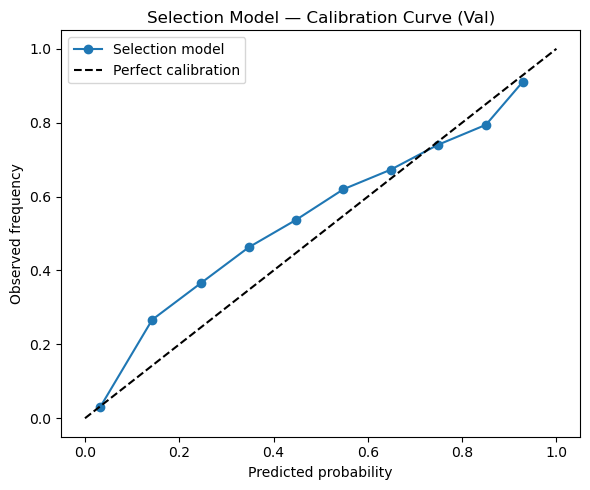

In [16]:
# ── Calibration curve for selection model ─────────────────
fig, ax = plt.subplots(1, 1, figsize=(6, 5))
prob_true, prob_pred = calibration_curve(y_sel_val, sel_proba_val, n_bins=10)
ax.plot(prob_pred, prob_true, "o-", label="Selection model")
ax.plot([0, 1], [0, 1], "k--", label="Perfect calibration")
ax.set_xlabel("Predicted probability")
ax.set_ylabel("Observed frequency")
ax.set_title("Selection Model — Calibration Curve (Val)")
ax.legend()
plt.tight_layout()
plt.show()

## 7. Model B: Outcome Model (Fresh or Rotten?)

In [17]:
# ── Build outcome training data (with as-of features) ─────
# For each review, build features from the reviews that came BEFORE it.
# This prevents the outcome model from seeing the final movie state.
#
# BATCHED: per movie, we look up critic & movie static features ONCE,
# then only compute the cheap dynamic snapshot per review.

# Pre-index critic features for O(1) lookup
_critic_feat_cols = [c for c in critic_features.columns if c != "critic_name"]
_critic_feat_idx = critic_features.set_index("critic_name")[_critic_feat_cols]
_critic_feat_default = np.zeros(len(_critic_feat_cols))

# Pre-index movie static features for O(1) lookup
_movie_meta_idx = movie_meta_small.set_index("movie_key")[movie_static_cols]
_movie_static_default = np.zeros(len(movie_static_cols))

# Dynamic snapshot column names
_DYN_COLS = ["n_obs_reviews", "obs_fresh_rate", "obs_top_critic_share",
             "obs_review_velocity", "obs_days_since_first"]
_RECENCY_COLS = [f"critic_recent_{w}d_reviews" for w in RECENT_WINDOWS_DAYS]

# Full column order for outcome rows
_ALL_OUT_COLS = _critic_feat_cols + _RECENCY_COLS + movie_static_cols + _DYN_COLS + ["is_fresh"]


def _dynamic_snapshot_vals(is_fresh_arr, is_top_arr, dates_arr, n_prefix):
    """Compute dynamic movie snapshot from prefix arrays (no DataFrame overhead)."""
    if n_prefix == 0:
        return [0.0, 0.0, 0.0, 0.0, 0.0]
    s_obs = int(is_fresh_arr[:n_prefix].sum())
    n_obs = n_prefix
    fresh_rate = s_obs / n_obs
    top_share = float(is_top_arr[:n_prefix].mean())
    fr = dates_arr[0]
    lr = dates_arr[n_prefix - 1]
    span = max((lr - fr) / np.timedelta64(1, 'D'), 1.0)
    velocity = n_obs / span
    return [float(n_obs), fresh_rate, top_share, velocity, span]


def build_outcome_dataset(reviews_df, critic_dates_map, max_rows=None):
    """Build dataset for outcome model with strict as-of features (batched)."""
    all_row_arrays = []
    grouped = list(reviews_df.groupby("movie_key"))
    total_rows = 0

    for mi, (mk, g) in enumerate(grouped, 1):
        if mi % PROGRESS_EVERY_MOVIES == 0:
            print(f"  outcome progress: {mi:,}/{len(grouped):,} movies, rows={total_rows:,}")

        m = dedup_movie_reviews(g)
        if len(m) == 0:
            continue
        m = m.sort_values(["review_date", "critic_name"]).reset_index(drop=True)

        # Pre-extract arrays for this movie (avoid repeated iloc)
        critics_list = m["critic_name"].values
        is_fresh_arr = m["is_fresh"].values.astype(np.float64)
        is_top_arr = m["is_top_critic"].values.astype(np.float64)
        dates_arr = m["review_date"].values.astype("datetime64[ns]")
        labels_arr = m["is_fresh"].values.astype(np.float64)

        # ONE movie static lookup
        if mk in _movie_meta_idx.index:
            movie_static_vals = _movie_meta_idx.loc[mk].values.astype(np.float64)
        else:
            movie_static_vals = _movie_static_default

        for i in range(len(m)):
            cn = critics_list[i]
            as_of64 = dates_arr[i]

            # Critic static features (O(1) index lookup)
            if cn in _critic_feat_idx.index:
                critic_vals = _critic_feat_idx.loc[cn].values.astype(np.float64)
            else:
                critic_vals = _critic_feat_default

            # Recency features (3 searchsorted calls)
            c_dates = critic_dates_map.get(cn)
            recency_vals = np.array([
                recent_count(c_dates, as_of64, w) for w in RECENT_WINDOWS_DAYS
            ], dtype=np.float64)

            # Dynamic movie snapshot from prefix
            dyn_vals = _dynamic_snapshot_vals(is_fresh_arr, is_top_arr, dates_arr, i)

            # Assemble row as single array
            row = np.concatenate([
                critic_vals, recency_vals, movie_static_vals,
                np.array(dyn_vals, dtype=np.float64),
                np.array([labels_arr[i]], dtype=np.float64),
            ])
            all_row_arrays.append(row)
            total_rows += 1

            if max_rows is not None and total_rows >= max_rows:
                print(f"  outcome capped at {total_rows:,} rows")
                return pd.DataFrame(all_row_arrays, columns=_ALL_OUT_COLS)

    if not all_row_arrays:
        return pd.DataFrame(columns=_ALL_OUT_COLS)
    return pd.DataFrame(all_row_arrays, columns=_ALL_OUT_COLS)


print("Building outcome datasets (batched, as-of features)...")
out_train_movie_set = set(limit_movie_keys(train_movies, MAX_OUTCOME_TRAIN_MOVIES, seed=RANDOM_SEED + 2))
out_val_movie_set = set(limit_movie_keys(val_movies, MAX_OUTCOME_VAL_MOVIES, seed=RANDOM_SEED + 3))
print(f"  Using train movies: {len(out_train_movie_set):,}/{len(train_movies):,}")
print(f"  Using val movies:   {len(out_val_movie_set):,}/{len(val_movies):,}")

out_train = build_outcome_dataset(
    df_train_univ[df_train_univ["movie_key"].isin(out_train_movie_set)],
    critic_dates_train, max_rows=MAX_OUTCOME_TRAIN_ROWS,
)
out_val = build_outcome_dataset(
    df_val_univ[df_val_univ["movie_key"].isin(out_val_movie_set)],
    critic_dates_all, max_rows=MAX_OUTCOME_VAL_ROWS,
)

# Downsample
out_train = downsample_binary_frame(out_train, "is_fresh", MAX_OUTCOME_TRAIN_ROWS, seed=RANDOM_SEED + 12)
out_val = downsample_binary_frame(out_val, "is_fresh", MAX_OUTCOME_VAL_ROWS, seed=RANDOM_SEED + 13)

OUT_META = ["critic_name", "is_fresh"]
OUT_FEATURE_COLS = [c for c in out_train.columns if c not in OUT_META]
out_train[OUT_FEATURE_COLS] = out_train[OUT_FEATURE_COLS].fillna(0)
out_val[OUT_FEATURE_COLS] = out_val[OUT_FEATURE_COLS].fillna(0)

print(f"Outcome train: {len(out_train):,} rows (fresh rate: {out_train['is_fresh'].mean():.3f})")
print(f"Outcome val:   {len(out_val):,} rows (fresh rate: {out_val['is_fresh'].mean():.3f})")

Building outcome datasets (batched, as-of features)...
  Using train movies: 3,500/10,501
  Using val movies:   559/559
  outcome progress: 100/3,500 movies, rows=5,644
  outcome progress: 200/3,500 movies, rows=9,275
  outcome progress: 300/3,500 movies, rows=17,043
  outcome progress: 400/3,500 movies, rows=26,206
  outcome progress: 500/3,500 movies, rows=34,577
  outcome progress: 600/3,500 movies, rows=43,665
  outcome progress: 700/3,500 movies, rows=51,628
  outcome progress: 800/3,500 movies, rows=60,136
  outcome progress: 900/3,500 movies, rows=69,003
  outcome progress: 1,000/3,500 movies, rows=75,797
  outcome progress: 1,100/3,500 movies, rows=83,373
  outcome progress: 1,200/3,500 movies, rows=91,886
  outcome progress: 1,300/3,500 movies, rows=100,073
  outcome progress: 1,400/3,500 movies, rows=107,578
  outcome progress: 1,500/3,500 movies, rows=116,204
  outcome progress: 1,600/3,500 movies, rows=125,167
  outcome progress: 1,700/3,500 movies, rows=133,518
  outcome p

In [18]:
X_out_train = out_train[OUT_FEATURE_COLS].values
y_out_train = out_train["is_fresh"].values
X_out_val = out_val[OUT_FEATURE_COLS].values
y_out_val = out_val["is_fresh"].values

if USE_LGBM:
    out_base = lgb.LGBMClassifier(
        n_estimators=150,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        min_child_samples=40,
        random_state=RANDOM_SEED,
        verbose=-1,
    )
    print("Training outcome model (LightGBM + sigmoid calibration, cv=2)...")
    out_model = CalibratedClassifierCV(out_base, cv=2, method="sigmoid")
    out_model.fit(X_out_train, y_out_train)
    scaler_out = None
else:
    scaler_out = StandardScaler()
    X_out_train = scaler_out.fit_transform(X_out_train)
    X_out_val = scaler_out.transform(X_out_val)
    out_base = LogisticRegression(
        C=1.0, class_weight="balanced", max_iter=400,
        solver="saga", random_state=RANDOM_SEED
    )
    print("Training outcome model (LogisticRegression + sigmoid calibration, cv=2)...")
    out_model = CalibratedClassifierCV(out_base, cv=2, method="sigmoid")
    out_model.fit(X_out_train, y_out_train)

out_proba_train = out_model.predict_proba(X_out_train)[:, 1]
out_proba_val = out_model.predict_proba(X_out_val)[:, 1]

print(f"\n{'='*50}")
print(f"OUTCOME MODEL RESULTS")
print(f"{'='*50}")
print(f"  Train AUC:      {roc_auc_score(y_out_train, out_proba_train):.4f}")
print(f"  Val AUC:        {roc_auc_score(y_out_val, out_proba_val):.4f}")
print(f"  Train Log Loss: {log_loss(y_out_train, out_proba_train):.4f}")
print(f"  Val Log Loss:   {log_loss(y_out_val, out_proba_val):.4f}")

Training outcome model (LightGBM + sigmoid calibration, cv=2)...

OUTCOME MODEL RESULTS
  Train AUC:      0.8385
  Val AUC:        0.8287
  Train Log Loss: 0.4766
  Val Log Loss:   0.4672


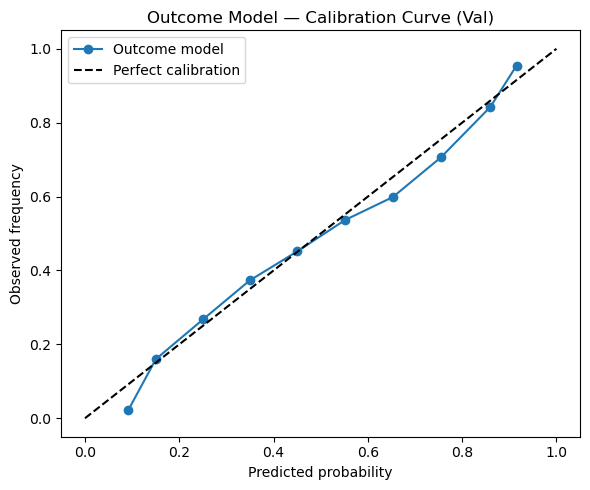

In [19]:
fig, ax = plt.subplots(1, 1, figsize=(6, 5))
prob_true_o, prob_pred_o = calibration_curve(y_out_val, out_proba_val, n_bins=10)
ax.plot(prob_pred_o, prob_true_o, "o-", label="Outcome model")
ax.plot([0, 1], [0, 1], "k--", label="Perfect calibration")
ax.set_xlabel("Predicted probability")
ax.set_ylabel("Observed frequency")
ax.set_title("Outcome Model — Calibration Curve (Val)")
ax.legend()
plt.tight_layout()
plt.show()

## 8. Combine: Expected Final Tomatometer

In [20]:
def predict_selection_remaining(
    movie_key, as_of, observed_prefix, remaining_critics,
):
    """Predict P(will review after as_of) for remaining critics using as-of features."""
    if not remaining_critics:
        return np.array([])
    f = build_candidate_frame(
        movie_key=movie_key, critics=remaining_critics, as_of=as_of,
        movie_prefix_reviews=observed_prefix, critic_dates_map=critic_dates_all,
    )
    X = f[FEATURE_COLS].values
    if scaler_sel is not None:
        X = scaler_sel.transform(X)
    return sel_model.predict_proba(X)[:, 1]


def predict_outcome_for_critics(
    movie_key, as_of, observed_prefix, critics,
):
    """Predict P(fresh | reviews) for critics using as-of features."""
    if not critics:
        return np.array([])
    f = build_candidate_frame(
        movie_key=movie_key, critics=critics, as_of=as_of,
        movie_prefix_reviews=observed_prefix, critic_dates_map=critic_dates_all,
    )
    X = f[OUT_FEATURE_COLS].values
    if scaler_out is not None:
        X = scaler_out.transform(X)
    return out_model.predict_proba(X)[:, 1]


print("As-of prediction functions defined.")

As-of prediction functions defined.


## 9. Live Nowcast Function (Monte Carlo)

In [21]:
def nowcast_movie(
    movie_key,
    as_of_datetime,
    n_sims=N_SIMS,
    thresholds=THRESHOLDS,
    chunk_size=512,
    seed=RANDOM_SEED,
):
    """
    Nowcast the final Tomatometer for a movie given reviews up to as_of_datetime.
    Uses strict as-of features — no future information leakage.
    """
    as_of = pd.Timestamp(as_of_datetime)

    m = df_all_univ[df_all_univ["movie_key"] == movie_key].copy()
    if len(m) == 0:
        raise ValueError(f"Unknown movie_key: {movie_key}")
    m = dedup_movie_reviews(m)
    m = m.sort_values(["review_date", "critic_name"]).reset_index(drop=True)
    obs = m[m["review_date"] <= as_of].copy()

    S_obs = int(obs["is_fresh"].sum())
    N_obs = len(obs)
    current_T = S_obs / N_obs if N_obs > 0 else 0.0
    observed_critics = set(obs["critic_name"])
    remaining = [c for c in CRITIC_UNIVERSE if c not in observed_critics]

    if len(remaining) == 0:
        sims = np.full(n_sims, current_T)
    else:
        # Get p (selection) and q (outcome) with as-of features
        p = predict_selection_remaining(movie_key, as_of, obs, remaining)
        q = predict_outcome_for_critics(movie_key, as_of, obs, remaining)
        p = np.clip(p, 1e-5, 1 - 1e-5)
        q = np.clip(q, 1e-5, 1 - 1e-5)

        rng = np.random.RandomState(seed)
        sims = np.empty(n_sims, dtype=float)
        n_rem = len(remaining)

        start = 0
        while start < n_sims:
            end = min(start + chunk_size, n_sims)
            bs = end - start
            U1 = rng.random((bs, n_rem))
            R = (U1 < p[np.newaxis, :]).astype(np.int16)
            U2 = rng.random((bs, n_rem))
            F = (U2 < q[np.newaxis, :]).astype(np.int16) * R
            new_n = R.sum(axis=1)
            new_s = F.sum(axis=1)
            tot_n = N_obs + new_n
            tot_s = S_obs + new_s
            sims[start:end] = np.where(tot_n > 0, tot_s / tot_n, 0.5)
            start = end

    result = {
        "movie_key": movie_key,
        "as_of": as_of,
        "point_estimate": float(np.mean(sims)),
        "median": float(np.median(sims)),
        "p5": float(np.percentile(sims, 5)),
        "p25": float(np.percentile(sims, 25)),
        "p75": float(np.percentile(sims, 75)),
        "p95": float(np.percentile(sims, 95)),
        "std": float(np.std(sims)),
        "threshold_probs": {t: float((sims >= t).mean()) for t in thresholds},
        "observed": {
            "S_obs": S_obs,
            "N_obs": N_obs,
            "current_T": current_T,
            "n_remaining_critics": len(remaining),
        },
        "simulations": sims,
    }
    return result


def print_nowcast(result):
    """Pretty-print a nowcast result."""
    obs = result["observed"]
    print(f"\n{'='*60}")
    print(f"  NOWCAST: {result['movie_key']}")
    print(f"  As of:   {result['as_of']}")
    print(f"{'='*60}")
    print(f"  Observed: {obs['S_obs']}/{obs['N_obs']} Fresh  "
          f"(current {obs['current_T']:.1%})")
    print(f"  Remaining critics in universe: {obs['n_remaining_critics']}")
    print(f"")
    print(f"  Point estimate (mean): {result['point_estimate']:.1%}")
    print(f"  Median:                {result['median']:.1%}")
    print(f"  90% CI:  [{result['p5']:.1%}, {result['p95']:.1%}]")
    print(f"  50% CI:  [{result['p25']:.1%}, {result['p75']:.1%}]")
    print(f"  Std dev:               {result['std']:.3f}")
    print(f"")
    print(f"  Threshold probabilities:")
    for t, p in result["threshold_probs"].items():
        print(f"    P(T >= {t:.0%}): {p:.1%}")


print("Nowcast function defined (leakage-safe).")

Nowcast function defined (leakage-safe).


In [22]:
# ── Quick demo on one validation movie ────────────────────
demo_mk = list(val_movies)[0]
demo_revs = df_val_univ[df_val_univ["movie_key"] == demo_mk].sort_values("review_date")
demo_actual_T = movie_stats[movie_stats["movie_key"] == demo_mk]["tomatometer"].values[0]

print(f"Demo movie: {demo_mk}")
print(f"Total reviews: {len(demo_revs)}, Actual final T: {demo_actual_T:.1%}")

# Nowcast after 5 reviews
if len(demo_revs) >= 5:
    as_of = demo_revs.iloc[4]["review_date"]
    result = nowcast_movie(demo_mk, as_of)
    print_nowcast(result)
    print(f"\n  ** Actual final Tomatometer: {demo_actual_T:.1%} **")

Demo movie: m/paddleton
Total reviews: 31, Actual final T: 90.2%

  NOWCAST: m/paddleton
  As of:   2019-01-31 00:00:00
  Observed: 5/5 Fresh  (current 100.0%)
  Remaining critics in universe: 2995

  Point estimate (mean): 86.7%
  Median:                86.7%
  90% CI:  [83.1%, 90.1%]
  50% CI:  [85.2%, 88.1%]
  Std dev:               0.022

  Threshold probabilities:
    P(T >= 60%): 100.0%
    P(T >= 70%): 100.0%
    P(T >= 80%): 99.9%
    P(T >= 90%): 5.8%

  ** Actual final Tomatometer: 90.2% **


## 10. Replay Backtest

In [23]:
def run_backtest(
    val_movie_keys, checkpoints=BACKTEST_CHECKPOINTS,
    n_sims=2000, max_movies=MAX_BACKTEST_MOVIES,
):
    """
    Run backtest: for each val movie, nowcast at each checkpoint and compare to actual.
    """
    results = []
    movie_list = list(val_movie_keys)[:max_movies]

    for i, mk in enumerate(movie_list):
        if (i + 1) % 20 == 0:
            print(f"  Backtesting movie {i+1}/{len(movie_list)}...")

        m = dedup_movie_reviews(df_all_univ[df_all_univ["movie_key"] == mk])
        m = m.sort_values(["review_date", "critic_name"]).reset_index(drop=True)
        if len(m) == 0:
            continue
        actual = float(m["is_fresh"].mean())
        total_n = len(m)

        for cp in checkpoints:
            if cp > total_n:
                continue
            as_of = pd.Timestamp(m.iloc[cp - 1]["review_date"])
            try:
                nc = nowcast_movie(mk, as_of, n_sims=n_sims, seed=RANDOM_SEED + i)
            except Exception as e:
                continue

            row = {
                "movie_key": mk,
                "checkpoint": cp,
                "pct_reviews_seen": cp / total_n,
                "actual_T": actual,
                "predicted_T": nc["point_estimate"],
                "median_T": nc["median"],
                "p5": nc["p5"],
                "p95": nc["p95"],
                "current_naive_T": nc["observed"]["current_T"],
                "error": nc["point_estimate"] - actual,
                "naive_error": nc["observed"]["current_T"] - actual,
            }
            for t in THRESHOLDS:
                t_int = int(t * 100)
                row[f"actual_above_{t_int}"] = int(actual >= t)
                row[f"pred_prob_{t_int}"] = nc["threshold_probs"][t]
            results.append(row)

    return pd.DataFrame(results)


print("Running backtest on validation movies...")
bt = run_backtest(val_movies, max_movies=MAX_BACKTEST_MOVIES, n_sims=1500)
print(f"Backtest complete: {len(bt)} predictions across {bt['movie_key'].nunique() if len(bt) else 0} movies")

Running backtest on validation movies...
  Backtesting movie 20/100...
  Backtesting movie 40/100...
  Backtesting movie 60/100...
  Backtesting movie 80/100...
  Backtesting movie 100/100...
Backtest complete: 319 predictions across 100 movies


In [24]:
# ── Backtest Metrics ──────────────────────────────────────
print(f"{'='*70}")
print(f"BACKTEST RESULTS")
print(f"{'='*70}")

for cp in BACKTEST_CHECKPOINTS:
    subset = bt[bt["checkpoint"] == cp]
    if len(subset) == 0:
        continue
    
    mae_model = mean_absolute_error(subset["actual_T"], subset["predicted_T"])
    rmse_model = np.sqrt(mean_squared_error(subset["actual_T"], subset["predicted_T"]))
    mae_naive = mean_absolute_error(subset["actual_T"], subset["current_naive_T"])
    rmse_naive = np.sqrt(mean_squared_error(subset["actual_T"], subset["current_naive_T"]))
    
    print(f"\n  After {cp} reviews (n={len(subset)} movies):")
    print(f"    MODEL  — MAE: {mae_model:.4f}  RMSE: {rmse_model:.4f}")
    print(f"    NAIVE  — MAE: {mae_naive:.4f}  RMSE: {rmse_naive:.4f}")
    print(f"    Improvement:   MAE {(1 - mae_model/mae_naive)*100:+.1f}%  RMSE {(1 - rmse_model/rmse_naive)*100:+.1f}%")

# Brier scores for threshold events
print(f"\n{'='*70}")
print(f"BRIER SCORES (lower is better)")
print(f"{'='*70}")

brier_rows = []
for cp in BACKTEST_CHECKPOINTS:
    subset = bt[bt["checkpoint"] == cp]
    if len(subset) == 0:
        continue
    row = {"checkpoint": cp, "n": len(subset)}
    for t in THRESHOLDS:
        t_int = int(t * 100)
        y_true = subset[f"actual_above_{t_int}"].values
        y_prob = subset[f"pred_prob_{t_int}"].values
        if len(np.unique(y_true)) > 1:
            brier = brier_score_loss(y_true, y_prob)
            row[f"Brier_>={t_int}%"] = f"{brier:.4f}"
        else:
            row[f"Brier_>={t_int}%"] = "N/A"
    brier_rows.append(row)

brier_df = pd.DataFrame(brier_rows)
print(brier_df.to_string(index=False))

BACKTEST RESULTS

  After 5 reviews (n=100 movies):
    MODEL  — MAE: 0.0988  RMSE: 0.1232
    NAIVE  — MAE: 0.1241  RMSE: 0.1581
    Improvement:   MAE +20.4%  RMSE +22.0%

  After 10 reviews (n=99 movies):
    MODEL  — MAE: 0.0754  RMSE: 0.0964
    NAIVE  — MAE: 0.0798  RMSE: 0.1061
    Improvement:   MAE +5.5%  RMSE +9.1%

  After 25 reviews (n=73 movies):
    MODEL  — MAE: 0.0480  RMSE: 0.0594
    NAIVE  — MAE: 0.0416  RMSE: 0.0557
    Improvement:   MAE -15.5%  RMSE -6.6%

  After 50 reviews (n=47 movies):
    MODEL  — MAE: 0.0351  RMSE: 0.0453
    NAIVE  — MAE: 0.0317  RMSE: 0.0419
    Improvement:   MAE -10.8%  RMSE -8.0%

BRIER SCORES (lower is better)
 checkpoint   n Brier_>=60% Brier_>=70% Brier_>=80% Brier_>=90%
          5 100      0.0934      0.1240      0.1781      0.1588
         10  99      0.0726      0.0838      0.1360      0.1298
         25  73      0.0496      0.0431      0.0683      0.0885
         50  47      0.0649      0.0405      0.0261      0.0487


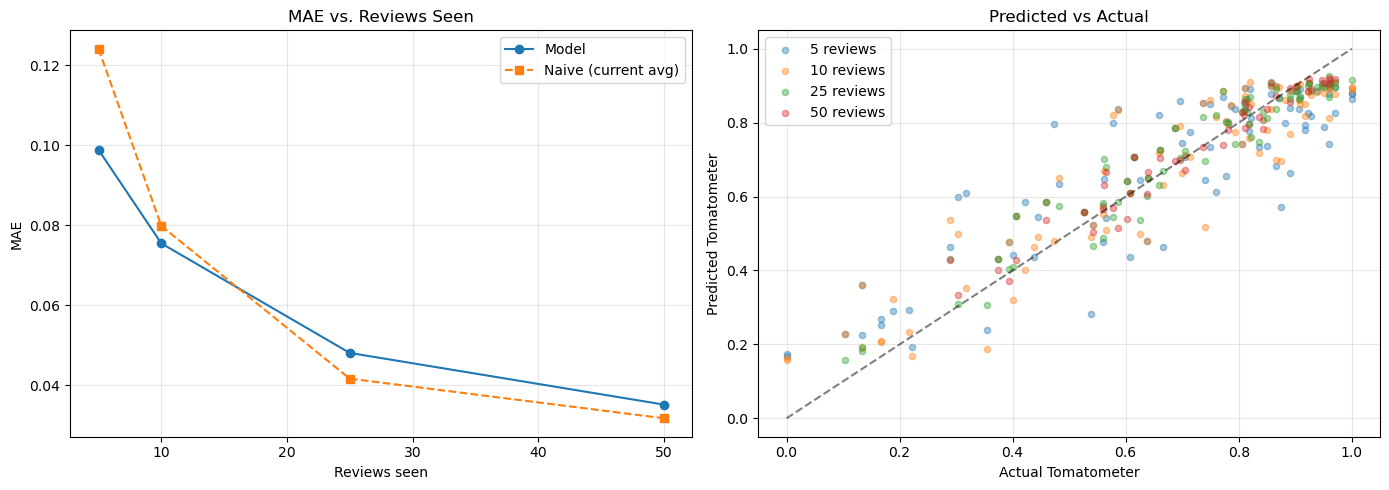

In [25]:
# ── Backtest visualization ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: MAE by checkpoint
ax = axes[0]
mae_data = []
for cp in BACKTEST_CHECKPOINTS:
    s = bt[bt["checkpoint"] == cp]
    if len(s) == 0:
        continue
    mae_data.append({
        "checkpoint": cp,
        "Model": mean_absolute_error(s["actual_T"], s["predicted_T"]),
        "Naive": mean_absolute_error(s["actual_T"], s["current_naive_T"]),
    })
mae_df = pd.DataFrame(mae_data)
ax.plot(mae_df["checkpoint"], mae_df["Model"], "o-", label="Model")
ax.plot(mae_df["checkpoint"], mae_df["Naive"], "s--", label="Naive (current avg)")
ax.set_xlabel("Reviews seen")
ax.set_ylabel("MAE")
ax.set_title("MAE vs. Reviews Seen")
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 2: Predicted vs Actual scatter
ax = axes[1]
for cp in BACKTEST_CHECKPOINTS:
    s = bt[bt["checkpoint"] == cp]
    if len(s) == 0:
        continue
    ax.scatter(s["actual_T"], s["predicted_T"], alpha=0.4, s=20, label=f"{cp} reviews")
ax.plot([0, 1], [0, 1], "k--", alpha=0.5)
ax.set_xlabel("Actual Tomatometer")
ax.set_ylabel("Predicted Tomatometer")
ax.set_title("Predicted vs Actual")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

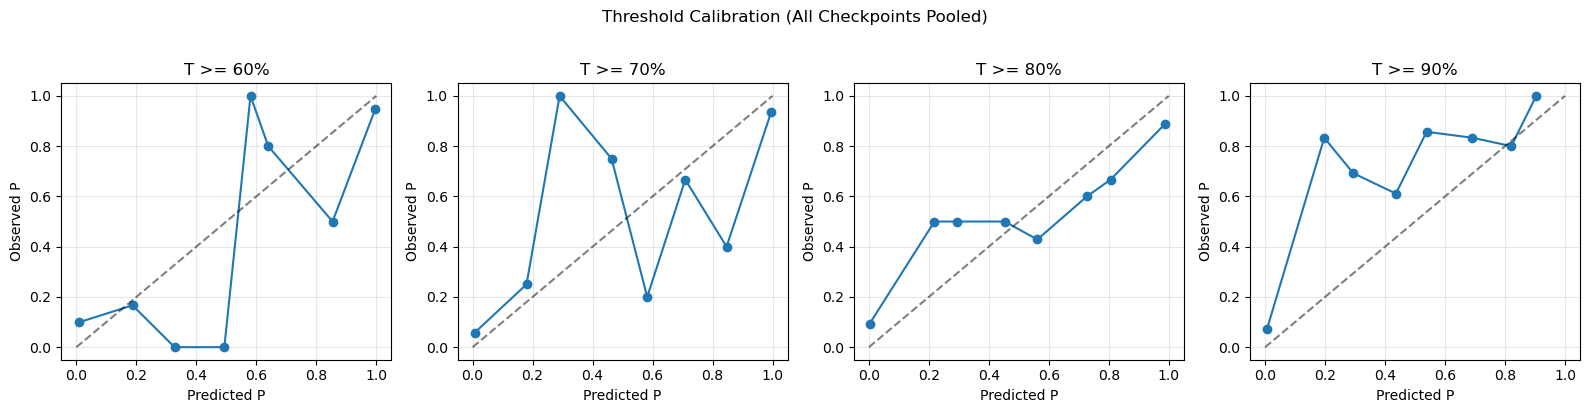

In [26]:
# ── Threshold calibration plots ───────────────────────────
fig, axes = plt.subplots(1, len(THRESHOLDS), figsize=(4 * len(THRESHOLDS), 4))
if len(THRESHOLDS) == 1:
    axes = [axes]

for ax, t in zip(axes, THRESHOLDS):
    t_int = int(t * 100)
    y_true = bt[f"actual_above_{t_int}"].values
    y_prob = bt[f"pred_prob_{t_int}"].values
    
    if len(np.unique(y_true)) < 2:
        ax.set_title(f">={t_int}% (insufficient data)")
        continue
    
    prob_true, prob_pred = calibration_curve(y_true, y_prob, n_bins=8)
    ax.plot(prob_pred, prob_true, "o-", label="Model")
    ax.plot([0, 1], [0, 1], "k--", alpha=0.5)
    ax.set_xlabel("Predicted P")
    ax.set_ylabel("Observed P")
    ax.set_title(f"T >= {t_int}%")
    ax.grid(True, alpha=0.3)

fig.suptitle("Threshold Calibration (All Checkpoints Pooled)", y=1.02)
plt.tight_layout()
plt.show()

## 11. Worked Example: Full Nowcast Timeline

In [27]:
# ── Pick a well-reviewed validation movie for the worked example ──
val_stats = movie_stats[movie_stats["movie_key"].isin(val_movies)].copy()
val_stats = val_stats.sort_values("n_reviews", ascending=False)

# Pick top movie by review count
example_mk = val_stats.iloc[0]["movie_key"]
example_actual_T = val_stats.iloc[0]["tomatometer"]
example_n = int(val_stats.iloc[0]["n_reviews"])

print(f"Worked example movie: {example_mk}")
print(f"Total reviews: {example_n}")
print(f"Actual final Tomatometer: {example_actual_T:.1%}")
print()

# Get sorted reviews
ex_revs = df_all_univ[df_all_univ["movie_key"] == example_mk].sort_values("review_date")

# Define checkpoints
ex_checkpoints = [5, 10, 25, 50, 100]
ex_checkpoints = [cp for cp in ex_checkpoints if cp <= len(ex_revs)]

timeline = []
for cp in ex_checkpoints:
    as_of = ex_revs.iloc[cp - 1]["review_date"]
    nc = nowcast_movie(example_mk, as_of, n_sims=5000)
    print_nowcast(nc)
    print(f"  ** Actual final Tomatometer: {example_actual_T:.1%} **")
    
    timeline.append({
        "reviews_seen": cp,
        "date": as_of,
        "current_T": nc["observed"]["current_T"],
        "predicted_T": nc["point_estimate"],
        "p5": nc["p5"],
        "p95": nc["p95"],
    })

Worked example movie: m/star_wars_the_rise_of_skywalker
Total reviews: 992
Actual final Tomatometer: 50.8%


  NOWCAST: m/star_wars_the_rise_of_skywalker
  As of:   2019-12-18 00:00:00
  Observed: 85/163 Fresh  (current 52.1%)
  Remaining critics in universe: 2837

  Point estimate (mean): 53.3%
  Median:                53.3%
  90% CI:  [50.2%, 56.3%]
  50% CI:  [52.0%, 54.5%]
  Std dev:               0.019

  Threshold probabilities:
    P(T >= 60%): 0.0%
    P(T >= 70%): 0.0%
    P(T >= 80%): 0.0%
    P(T >= 90%): 0.0%
  ** Actual final Tomatometer: 50.8% **

  NOWCAST: m/star_wars_the_rise_of_skywalker
  As of:   2019-12-18 00:00:00
  Observed: 85/163 Fresh  (current 52.1%)
  Remaining critics in universe: 2837

  Point estimate (mean): 53.3%
  Median:                53.3%
  90% CI:  [50.2%, 56.3%]
  50% CI:  [52.0%, 54.5%]
  Std dev:               0.019

  Threshold probabilities:
    P(T >= 60%): 0.0%
    P(T >= 70%): 0.0%
    P(T >= 80%): 0.0%
    P(T >= 90%): 0.0%
  ** Actual fi

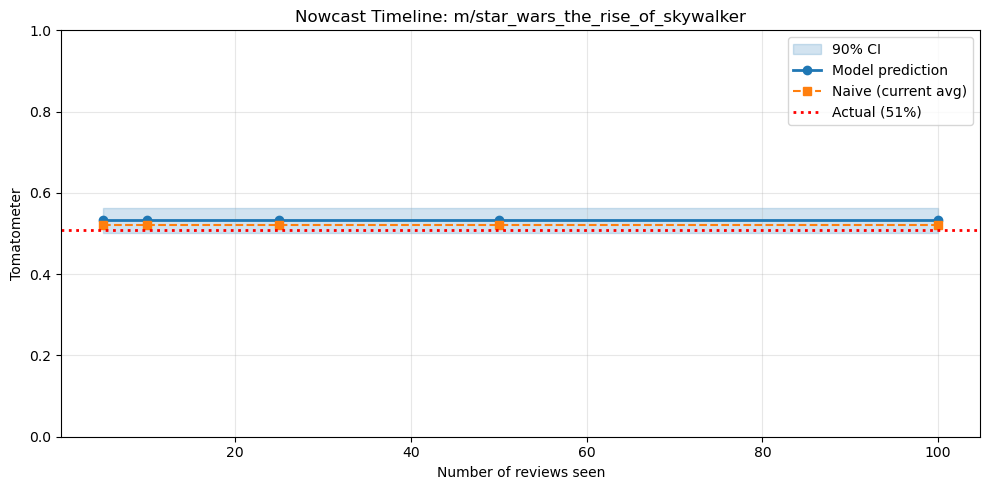

In [28]:
# ── Timeline visualization ────────────────────────────────
if len(timeline) > 1:
    tl = pd.DataFrame(timeline)
    
    fig, ax = plt.subplots(figsize=(10, 5))
    
    ax.fill_between(tl["reviews_seen"], tl["p5"], tl["p95"],
                    alpha=0.2, color="C0", label="90% CI")
    ax.plot(tl["reviews_seen"], tl["predicted_T"], "o-", color="C0",
            label="Model prediction", linewidth=2)
    ax.plot(tl["reviews_seen"], tl["current_T"], "s--", color="C1",
            label="Naive (current avg)", linewidth=1.5)
    ax.axhline(y=example_actual_T, color="red", linestyle=":",
               linewidth=2, label=f"Actual ({example_actual_T:.0%})")
    
    ax.set_xlabel("Number of reviews seen")
    ax.set_ylabel("Tomatometer")
    ax.set_title(f"Nowcast Timeline: {example_mk}")
    ax.legend()
    ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("Not enough checkpoints for a timeline plot.")

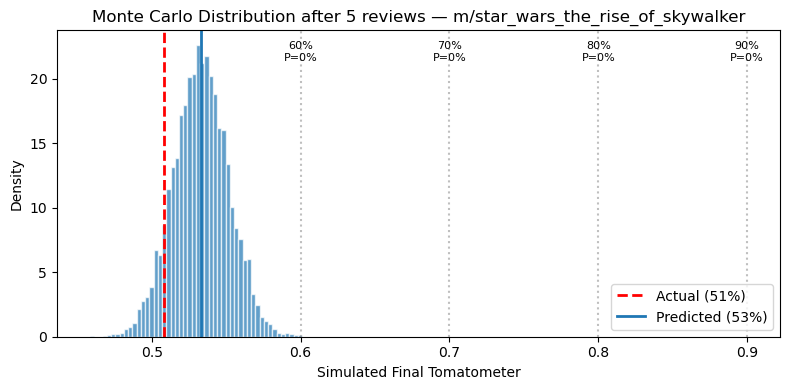

In [29]:
# ── Histogram of final simulation at earliest checkpoint ──
if len(ex_checkpoints) > 0:
    early_cp = ex_checkpoints[0]
    as_of = ex_revs.iloc[early_cp - 1]["review_date"]
    nc = nowcast_movie(example_mk, as_of, n_sims=10000)
    
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.hist(nc["simulations"], bins=50, density=True, alpha=0.7, color="C0",
            edgecolor="white")
    ax.axvline(x=example_actual_T, color="red", linestyle="--", linewidth=2,
               label=f"Actual ({example_actual_T:.0%})")
    ax.axvline(x=nc["point_estimate"], color="C0", linestyle="-", linewidth=2,
               label=f"Predicted ({nc['point_estimate']:.0%})")
    
    # Mark thresholds
    for t in THRESHOLDS:
        p = nc["threshold_probs"][t]
        ax.axvline(x=t, color="gray", linestyle=":", alpha=0.5)
        ax.text(t, ax.get_ylim()[1] * 0.9, f"{t:.0%}\nP={p:.0%}",
                ha="center", fontsize=8)
    
    ax.set_xlabel("Simulated Final Tomatometer")
    ax.set_ylabel("Density")
    ax.set_title(f"Monte Carlo Distribution after {early_cp} reviews — {example_mk}")
    ax.legend()
    plt.tight_layout()
    plt.show()

## 12. Summary

In [30]:
# ── Summary table of backtest results ─────────────────────
summary_rows = []
for cp in BACKTEST_CHECKPOINTS:
    s = bt[bt["checkpoint"] == cp]
    if len(s) == 0:
        continue
    row = {
        "Reviews Seen": cp,
        "N Movies": len(s),
        "Model MAE": f"{mean_absolute_error(s['actual_T'], s['predicted_T']):.4f}",
        "Naive MAE": f"{mean_absolute_error(s['actual_T'], s['current_naive_T']):.4f}",
        "Model RMSE": f"{np.sqrt(mean_squared_error(s['actual_T'], s['predicted_T'])):.4f}",
        "Naive RMSE": f"{np.sqrt(mean_squared_error(s['actual_T'], s['current_naive_T'])):.4f}",
    }
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)
print("BACKTEST SUMMARY")
print("=" * 80)
print(summary_df.to_string(index=False))
print("\nBrier scores by threshold:")
print(brier_df.to_string(index=False))
print("\n" + "=" * 80)
print("Model compares predicted final Tomatometer against the naive baseline")
print("(which simply uses the current average of observed reviews).")
print("Lower MAE/RMSE/Brier = better.")

BACKTEST SUMMARY
 Reviews Seen  N Movies Model MAE Naive MAE Model RMSE Naive RMSE
            5       100    0.0988    0.1241     0.1232     0.1581
           10        99    0.0754    0.0798     0.0964     0.1061
           25        73    0.0480    0.0416     0.0594     0.0557
           50        47    0.0351    0.0317     0.0453     0.0419

Brier scores by threshold:
 checkpoint   n Brier_>=60% Brier_>=70% Brier_>=80% Brier_>=90%
          5 100      0.0934      0.1240      0.1781      0.1588
         10  99      0.0726      0.0838      0.1360      0.1298
         25  73      0.0496      0.0431      0.0683      0.0885
         50  47      0.0649      0.0405      0.0261      0.0487

Model compares predicted final Tomatometer against the naive baseline
(which simply uses the current average of observed reviews).
Lower MAE/RMSE/Brier = better.


In [31]:
print("Notebook complete.")
print(f"\nDataset: {CSV_PATH}")
print(f"Train movies: {len(train_movies):,} | Val movies: {len(val_movies):,}")
print(f"Critic universe: {n_critics:,}")
print(f"Cutoff date: {CUTOFF_DATE}")
print(f"\nTo nowcast a specific movie:")
print(f'  result = nowcast_movie("m/movie_slug", "2019-06-15")')
print(f'  print_nowcast(result)')

Notebook complete.

Dataset: rotten_tomatoes_critic_reviews.csv
Train movies: 10,501 | Val movies: 559
Critic universe: 3,000
Cutoff date: 2019-01-01

To nowcast a specific movie:
  result = nowcast_movie("m/movie_slug", "2019-06-15")
  print_nowcast(result)


## 13. Nowcasting a New Movie (Wuthering Heights Example)

To nowcast a movie **not in the original CSV**, you need to:
1. Create a DataFrame of its early reviews (critic_name, is_fresh, review_date)
2. Register its movie-level features in `movie_features_all`
3. Append reviews to `df`
4. Call `nowcast_movie`

The helper `register_new_movie()` below handles steps 2-3.

In [51]:
def register_new_movie(movie_key, reviews_list, release_month=None, genres=None):
    """
    Register (or re-register) a movie for nowcasting. Idempotent — safe to call
    multiple times; old entries for this movie_key are removed first.
    """
    global df_all_univ, movie_meta_small, movie_features_all, movie_genre_all_df
    
    # ── Remove any previous registration of this movie ────
    df_all_univ = df_all_univ[df_all_univ["movie_key"] != movie_key].copy()
    
    new_revs = pd.DataFrame(reviews_list)
    new_revs["critic_name"] = new_revs["critic_name"].str.strip().str.lower()
    new_revs["review_date"] = pd.to_datetime(new_revs["review_date"])
    new_revs["is_fresh"] = new_revs["is_fresh"].astype(int)
    new_revs["movie_key"] = movie_key
    new_revs["is_top_critic"] = 0
    if "outlet" not in new_revs.columns:
        new_revs["outlet"] = "unknown"
    
    # Set genre columns
    if HAS_GENRES and GENRE_COLS:
        for col in GENRE_COLS:
            new_revs[col] = 0
        if genres:
            for g in genres:
                g_lower = g.lower().replace(' ', '_').replace('-', '_')
                matching = [c for c in GENRE_COLS if g_lower in c]
                for mc in matching:
                    new_revs[mc] = 1
    
    # Add to df_all_univ (used by nowcast_movie)
    for c in df_all_univ.columns:
        if c not in new_revs.columns:
            new_revs[c] = np.nan
    df_all_univ = pd.concat([df_all_univ, new_revs[df_all_univ.columns]], ignore_index=True)
    
    # Build static movie features row for movie_meta_small
    first_date = new_revs["review_date"].min()
    r_month = release_month if release_month else first_date.month
    
    mf_row = {"movie_key": movie_key}
    mf_row["movie_release_month"] = r_month
    mf_row["movie_release_quarter"] = (r_month - 1) // 3 + 1
    mf_row["movie_release_year"] = first_date.year
    
    if HAS_GENRES and GENRE_COLS:
        for col in GENRE_COLS:
            mf_row[col] = int(new_revs[col].max()) if col in new_revs.columns else 0
    
    rev_critics = set(new_revs["critic_name"]) & set(critic_to_idx.keys())
    new_vec = np.zeros((1, n_critics))
    for c in rev_critics:
        new_vec[0, critic_to_idx[c]] = 1.0
    if new_vec.sum() > 0:
        W_new = nmf_model.transform(csr_matrix(new_vec))
        W_new_norm = W_new / (W_new.sum() + 1e-8)
    else:
        W_new_norm = np.full((1, N_LATENT_GENRES), 1.0 / N_LATENT_GENRES)
    for i, col in enumerate(LATENT_GENRE_COLS):
        mf_row[col] = float(W_new_norm[0, i])
    
    for c in movie_static_cols:
        if c not in mf_row:
            mf_row[c] = 0.0
    
    mf_df = pd.DataFrame([mf_row])
    movie_meta_small = movie_meta_small[movie_meta_small["movie_key"] != movie_key]
    movie_meta_small = pd.concat([movie_meta_small, mf_df[["movie_key"] + movie_static_cols]], ignore_index=True)
    
    genre_row = pd.DataFrame(W_new_norm, columns=LATENT_GENRE_COLS)
    genre_row["movie_key"] = movie_key
    movie_genre_all_df = movie_genre_all_df[movie_genre_all_df["movie_key"] != movie_key]
    movie_genre_all_df = pd.concat([movie_genre_all_df, genre_row], ignore_index=True)
    
    # Rebuild critic dates (remove old dates from this movie's critics, add fresh)
    # We rebuild from df_all_univ which already has the clean state
    affected_critics = set(new_revs["critic_name"]) & critic_set
    for cn in affected_critics:
        all_dates = df_all_univ[df_all_univ["critic_name"] == cn]["review_date"].sort_values().values.astype("datetime64[ns]")
        critic_dates_all[cn] = all_dates
    
    genre_str = ", ".join(genres) if genres else "none specified"
    print(f"Registered '{movie_key}': {len(new_revs)} reviews, fresh rate {new_revs['is_fresh'].mean():.0%}")
    print(f"  Genres: {genre_str}")
    return new_revs

print("register_new_movie() defined — safe to call multiple times.")

register_new_movie() defined — safe to call multiple times.


In [52]:
# ── Example: Wuthering Heights ────────────────────────────
# Fill in real early reviews here. Critic names should be lowercase
# and ideally match names in CRITIC_UNIVERSE for best results.
# (To see available critics: print(CRITIC_UNIVERSE[:50]))
#
# You can check if a critic is in the universe:
#   "peter bradshaw" in set(CRITIC_UNIVERSE)

REVIEW_DATE = "2026-02-09"  # all were listed as "6d"

wuthering_reviews = [
    {"critic_name": "sebastian zavala kahn", "is_fresh": 0, "review_date": "2026-02-16"},
    {"critic_name": "rua fay", "is_fresh": 0, "review_date": "2026-02-16"},
    {"critic_name": "erik childress", "is_fresh": 0, "review_date": "2026-02-16"},
    {"critic_name": "keri o'shea", "is_fresh": 1, "review_date": "2026-02-16"},
    {"critic_name": "tina kakadelis", "is_fresh": 0, "review_date": "2026-02-16"},
    {"critic_name": "keith uhlich", "is_fresh": 0, "review_date": "2026-02-16"},
    {"critic_name": "sarah vincent", "is_fresh": 1, "review_date": "2026-02-16"},
    {"critic_name": "terence johnson", "is_fresh": 0, "review_date": "2026-02-16"},

    {"critic_name": "alan french", "is_fresh": 1, "review_date": "2026-02-15"},
    {"critic_name": "melissa strong", "is_fresh": 0, "review_date": "2026-02-15"},
    {"critic_name": "hannah lodge", "is_fresh": 0, "review_date": "2026-02-15"},
    {"critic_name": "keith garlington", "is_fresh": 0, "review_date": "2026-02-15"},
    {"critic_name": "dana han-klein", "is_fresh": 0, "review_date": "2026-02-15"},
    {"critic_name": "jack martin", "is_fresh": 0, "review_date": "2026-02-15"},
    {"critic_name": "simon foster", "is_fresh": 1, "review_date": "2026-02-15"},
    {"critic_name": "jeff york", "is_fresh": 0, "review_date": "2026-02-15"},
    {"critic_name": "nandini ramnath", "is_fresh": 0, "review_date": "2026-02-15"},

    {"critic_name": "marianna neal", "is_fresh": 0, "review_date": "2026-02-14"},
    {"critic_name": "natasha alvar", "is_fresh": 1, "review_date": "2026-02-14"},
    {"critic_name": "patrick mcdonald", "is_fresh": 1, "review_date": "2026-02-14"},
    {"critic_name": "peter travers", "is_fresh": 1, "review_date": "2026-02-14"},
    {"critic_name": "adam graham", "is_fresh": 1, "review_date": "2026-02-14"},
    {"critic_name": "daniel barnes", "is_fresh": 1, "review_date": "2026-02-14"},
    {"critic_name": "andrea zamora", "is_fresh": 1, "review_date": "2026-02-14"},
    {"critic_name": "carlos boyero", "is_fresh": 0, "review_date": "2026-02-14"},
    {"critic_name": "sarah marrs", "is_fresh": 0, "review_date": "2026-02-14"},
    {"critic_name": "robert horton", "is_fresh": 0, "review_date": "2026-02-14"},
    {"critic_name": "doug jamieson", "is_fresh": 1, "review_date": "2026-02-14"},
    {"critic_name": "dana stevens", "is_fresh": 1, "review_date": "2026-02-14"},
    {"critic_name": "matthew koss", "is_fresh": 1, "review_date": "2026-02-14"},
    {"critic_name": "mike mcgranaghan", "is_fresh": 1, "review_date": "2026-02-14"},
    {"critic_name": "pablo villaça", "is_fresh": 0, "review_date": "2026-02-14"},
    {"critic_name": "sean collier", "is_fresh": 1, "review_date": "2026-02-14"},
    {"critic_name": "annie berke", "is_fresh": 1, "review_date": "2026-02-14"},
    {"critic_name": "rebecca johnson", "is_fresh": 1, "review_date": "2026-02-14"},
    {"critic_name": "laura clifford", "is_fresh": 0, "review_date": "2026-02-14"},
    {"critic_name": "shalini langer", "is_fresh": 0, "review_date": "2026-02-14"},
    {"critic_name": "patrick beatty", "is_fresh": 0, "review_date": "2026-02-14"},
    {"critic_name": "john lui", "is_fresh": 1, "review_date": "2026-02-14"},
    {"critic_name": "renuka vyavahare", "is_fresh": 1, "review_date": "2026-02-14"},
    {"critic_name": "alex bentley", "is_fresh": 0, "review_date": "2026-02-14"},
    {"critic_name": "jordy sirkin", "is_fresh": 1, "review_date": "2026-02-14"},
    {"critic_name": "todd jorgenson", "is_fresh": 0, "review_date": "2026-02-14"},
    {"critic_name": "sarah marloff", "is_fresh": 0, "review_date": "2026-02-14"},
    {"critic_name": "shawn edwards", "is_fresh": 1, "review_date": "2026-02-14"},
    {"critic_name": "alci rengifo", "is_fresh": 0, "review_date": "2026-02-14"},
    {"critic_name": "bradley gibson", "is_fresh": 1, "review_date": "2026-02-14"},
    {"critic_name": "mark kermode", "is_fresh": 1, "review_date": "2026-02-14"},
    {"critic_name": "marya e. gates", "is_fresh": 1, "review_date": "2026-02-14"},
    {"critic_name": "victoria luxford", "is_fresh": 1, "review_date": "2026-02-14"},
    {"critic_name": "jeffrey harris", "is_fresh": 0, "review_date": "2026-02-14"},
    {"critic_name": "erick estrada", "is_fresh": 0, "review_date": "2026-02-14"},
    {"critic_name": "matt rodriguez", "is_fresh": 0, "review_date": "2026-02-14"},
    {"critic_name": "matthew creith", "is_fresh": 1, "review_date": "2026-02-14"},
    {"critic_name": "micheal compton", "is_fresh": 1, "review_date": "2026-02-14"},
    {"critic_name": "rick romancito", "is_fresh": 1, "review_date": "2026-02-14"},
    {"critic_name": "rain jokinen", "is_fresh": 1, "review_date": "2026-02-14"},
    {"critic_name": "jonathan w. hickman", "is_fresh": 1, "review_date": "2026-02-14"},
    {"critic_name": "steven prokopy", "is_fresh": 1, "review_date": "2026-02-14"},
    {"critic_name": "oscar goff", "is_fresh": 1, "review_date": "2026-02-14"},
    {"critic_name": "jackson weaver", "is_fresh": 0, "review_date": "2026-02-14"},
    {"critic_name": "karen gordon", "is_fresh": 1, "review_date": "2026-02-14"},
    {"critic_name": "paul klein", "is_fresh": 0, "review_date": "2026-02-14"},
    {"critic_name": "katherine mclaughlin", "is_fresh": 1, "review_date": "2026-02-14"},
    {"critic_name": "leo brady", "is_fresh": 1, "review_date": "2026-02-14"},
    {"critic_name": "ria dhull", "is_fresh": 1, "review_date": "2026-02-14"},
    {"critic_name": "sarah manvel", "is_fresh": 1, "review_date": "2026-02-14"},

    {"critic_name": "yasser medina", "is_fresh": 0, "review_date": "2026-02-13"},
    {"critic_name": "eric marchen", "is_fresh": 0, "review_date": "2026-02-13"},
    {"critic_name": "troy ribeiro", "is_fresh": 1, "review_date": "2026-02-13"},
    {"critic_name": "richard crouse", "is_fresh": 1, "review_date": "2026-02-13"},
    {"critic_name": "lauren bradshaw", "is_fresh": 1, "review_date": "2026-02-13"},
    {"critic_name": "julian lytle", "is_fresh": 1, "review_date": "2026-02-13"},
    {"critic_name": "james mottram", "is_fresh": 1, "review_date": "2026-02-13"},
    {"critic_name": "kate sánchez", "is_fresh": 0, "review_date": "2026-02-13"},
    {"critic_name": "brian orndorf", "is_fresh": 0, "review_date": "2026-02-13"},
    {"critic_name": "prabhjot bains", "is_fresh": 1, "review_date": "2026-02-13"},
    {"critic_name": "deborah ross", "is_fresh": 0, "review_date": "2026-02-13"},
    {"critic_name": "robert denerstein", "is_fresh": 0, "review_date": "2026-02-13"},
    {"critic_name": "barry hertz", "is_fresh": 0, "review_date": "2026-02-13"},
    {"critic_name": "ray pride", "is_fresh": 1, "review_date": "2026-02-13"},
    {"critic_name": "janire zurbano", "is_fresh": 1, "review_date": "2026-02-13"},
    {"critic_name": "manohla dargis", "is_fresh": 0, "review_date": "2026-02-13"},
    {"critic_name": "frank swietek", "is_fresh": 0, "review_date": "2026-02-13"},
    {"critic_name": "laura pérez", "is_fresh": 1, "review_date": "2026-02-13"},
    {"critic_name": "pablo o. scholz", "is_fresh": 0, "review_date": "2026-02-13"},
    {"critic_name": "juanma fernández parís", "is_fresh": 1, "review_date": "2026-02-13"},
    {"critic_name": "nelson acosta", "is_fresh": 1, "review_date": "2026-02-13"},
    {"critic_name": "paula vázquez prieto", "is_fresh": 1, "review_date": "2026-02-13"},
    {"critic_name": "danielle solzman", "is_fresh": 0, "review_date": "2026-02-13"},
    {"critic_name": "keith phipps", "is_fresh": 0, "review_date": "2026-02-13"},
    {"critic_name": "caralynn matassa", "is_fresh": 1, "review_date": "2026-02-13"},
    {"critic_name": "mark dujsik", "is_fresh": 1, "review_date": "2026-02-13"},
    {"critic_name": "allison rose", "is_fresh": 1, "review_date": "2026-02-13"},
    {"critic_name": "fico cangiano", "is_fresh": 1, "review_date": "2026-02-13"},
    {"critic_name": "christian craig", "is_fresh": 0, "review_date": "2026-02-13"},
    {"critic_name": "stephen silver", "is_fresh": 1, "review_date": "2026-02-13"},
    {"critic_name": "katie smith-wong", "is_fresh": 0, "review_date": "2026-02-13"},
    {"critic_name": "peter gray", "is_fresh": 1, "review_date": "2026-02-13"},
    {"critic_name": "jeanne kaplan", "is_fresh": 1, "review_date": "2026-02-13"},
    {"critic_name": "david kaplan", "is_fresh": 1, "review_date": "2026-02-13"},

    {"critic_name": "nadya martinez", "is_fresh": 0, "review_date": "2026-02-12"},
    {"critic_name": "katie walsh", "is_fresh": 0, "review_date": "2026-02-12"},
    {"critic_name": "lady jenevia", "is_fresh": 0, "review_date": "2026-02-12"},
    {"critic_name": "dionar hidalgo", "is_fresh": 1, "review_date": "2026-02-12"},
    {"critic_name": "philippa hawker", "is_fresh": 0, "review_date": "2026-02-12"},
    {"critic_name": "shahbaz siddiqui", "is_fresh": 1, "review_date": "2026-02-12"},
    {"critic_name": "rafer guzman", "is_fresh": 1, "review_date": "2026-02-12"},
    {"critic_name": "richard whittaker", "is_fresh": 0, "review_date": "2026-02-12"},
    {"critic_name": "luis martínez", "is_fresh": 0, "review_date": "2026-02-12"},
    {"critic_name": "kevin a. ranson", "is_fresh": 1, "review_date": "2026-02-12"},
    {"critic_name": "david sexton", "is_fresh": 0, "review_date": "2026-02-12"},
    {"critic_name": "david fear", "is_fresh": 1, "review_date": "2026-02-12"},
    {"critic_name": "moira macdonald", "is_fresh": 1, "review_date": "2026-02-12"},
    {"critic_name": "amanda luberto", "is_fresh": 1, "review_date": "2026-02-12"},
    {"critic_name": "nell minow", "is_fresh": 0, "review_date": "2026-02-12"},
    {"critic_name": "peter sobczynski", "is_fresh": 0, "review_date": "2026-02-12"},
    {"critic_name": "george simpson", "is_fresh": 1, "review_date": "2026-02-12"},
    {"critic_name": "brian viner", "is_fresh": 0, "review_date": "2026-02-12"},
    {"critic_name": "helen hawkins", "is_fresh": 0, "review_date": "2026-02-12"},
    {"critic_name": "amy nicholson", "is_fresh": 0, "review_date": "2026-02-12"},
    {"critic_name": "gregory nussen", "is_fresh": 0, "review_date": "2026-02-12"},
    {"critic_name": "diego batlle", "is_fresh": 0, "review_date": "2026-02-12"},
    {"critic_name": "beth webb", "is_fresh": 1, "review_date": "2026-02-12"},
    {"critic_name": "damon wise", "is_fresh": 0, "review_date": "2026-02-12"},
    {"critic_name": "laia cabuli", "is_fresh": 1, "review_date": "2026-02-12"},
    {"critic_name": "christian toto", "is_fresh": 1, "review_date": "2026-02-12"},
    {"critic_name": "jericho tadeo", "is_fresh": 0, "review_date": "2026-02-12"},
    {"critic_name": "mick lasalle", "is_fresh": 0, "review_date": "2026-02-12"},
    {"critic_name": "neil pond", "is_fresh": 1, "review_date": "2026-02-12"},
    {"critic_name": "ruchika bhat", "is_fresh": 1, "review_date": "2026-02-12"},
    {"critic_name": "sean burns", "is_fresh": 1, "review_date": "2026-02-12"},
    {"critic_name": "jeff nelson", "is_fresh": 1, "review_date": "2026-02-12"},

    {"critic_name": "scott mendelson", "is_fresh": 1, "review_date": "2026-02-11"},
    {"critic_name": "joanna langfield", "is_fresh": 1, "review_date": "2026-02-11"},
    {"critic_name": "casey chong", "is_fresh": 0, "review_date": "2026-02-11"},
    {"critic_name": "ben allen", "is_fresh": 1, "review_date": "2026-02-11"},
    {"critic_name": "rich cline", "is_fresh": 1, "review_date": "2026-02-11"},
    {"critic_name": "roberto tyler ortiz", "is_fresh": 1, "review_date": "2026-02-11"},
    {"critic_name": "andrea chase", "is_fresh": 1, "review_date": "2026-02-11"},
    {"critic_name": "rachel wagner", "is_fresh": 0, "review_date": "2026-02-11"},
    {"critic_name": "david poland", "is_fresh": 1, "review_date": "2026-02-11"},
    {"critic_name": "mike ryan", "is_fresh": 1, "review_date": "2026-02-11"},
    {"critic_name": "andrea thompson", "is_fresh": 0, "review_date": "2026-02-11"},
    {"critic_name": "tara mcnamara", "is_fresh": 1, "review_date": "2026-02-11"},
    {"critic_name": "george and josh bate", "is_fresh": 1, "review_date": "2026-02-11"},
    {"critic_name": "jeremy jahns", "is_fresh": 0, "review_date": "2026-02-11"},
    {"critic_name": "francesca steele", "is_fresh": 1, "review_date": "2026-02-11"},
    {"critic_name": "johnny oleksinski", "is_fresh": 1, "review_date": "2026-02-11"},
    {"critic_name": "leigh paatsch", "is_fresh": 1, "review_date": "2026-02-11"},
    {"critic_name": "peter howell", "is_fresh": 1, "review_date": "2026-02-11"},
    {"critic_name": "travis hopson", "is_fresh": 1, "review_date": "2026-02-11"},
    {"critic_name": "wendy ide", "is_fresh": 1, "review_date": "2026-02-11"},
    {"critic_name": "odie henderson", "is_fresh": 0, "review_date": "2026-02-11"},
    {"critic_name": "leonie cooper", "is_fresh": 1, "review_date": "2026-02-11"},
    {"critic_name": "dulcie pearce", "is_fresh": 1, "review_date": "2026-02-11"},
    {"critic_name": "clarisse loughrey", "is_fresh": 0, "review_date": "2026-02-11"},
    {"critic_name": "lindsey bahr", "is_fresh": 0, "review_date": "2026-02-11"},
    {"critic_name": "nikki gemmell", "is_fresh": 1, "review_date": "2026-02-11"},
    {"critic_name": "radhika seth", "is_fresh": 1, "review_date": "2026-02-11"},
    {"critic_name": "chris bumbray", "is_fresh": 1, "review_date": "2026-02-11"},
    {"critic_name": "william bibbiani", "is_fresh": 0, "review_date": "2026-02-11"},
    {"critic_name": "matt goldberg", "is_fresh": 0, "review_date": "2026-02-11"},
    {"critic_name": "matt oakes", "is_fresh": 1, "review_date": "2026-02-11"},
    {"critic_name": "jeanine t. abraham", "is_fresh": 1, "review_date": "2026-02-11"},
    {"critic_name": "nate adams", "is_fresh": 1, "review_date": "2026-02-11"},
    {"critic_name": "ethan vestby", "is_fresh": 0, "review_date": "2026-02-11"},
    {"critic_name": "matt maytum", "is_fresh": 1, "review_date": "2026-02-11"},
    {"critic_name": "jim schembri", "is_fresh": 1, "review_date": "2026-02-11"},
    {"critic_name": "calum cooper", "is_fresh": 1, "review_date": "2026-02-11"},
    {"critic_name": "henry wong", "is_fresh": 1, "review_date": "2026-02-11"},
    {"critic_name": "robert hutton", "is_fresh": 0, "review_date": "2026-02-11"},
    {"critic_name": "gabriella geisinger", "is_fresh": 1, "review_date": "2026-02-11"},
    {"critic_name": "avi offer", "is_fresh": 1, "review_date": "2026-02-11"},

    {"critic_name": "tyler taing", "is_fresh": 1, "review_date": "2026-02-10"},
    {"critic_name": "kristy puchko", "is_fresh": 0, "review_date": "2026-02-10"},
    {"critic_name": "lupe rodriguez haas", "is_fresh": 1, "review_date": "2026-02-10"},
    {"critic_name": "wenlei ma", "is_fresh": 1, "review_date": "2026-02-10"},
    {"critic_name": "carla hay", "is_fresh": 1, "review_date": "2026-02-10"},
    {"critic_name": "siddhant adlakha", "is_fresh": 0, "review_date": "2026-02-10"},
    {"critic_name": "brandon lewis", "is_fresh": 0, "review_date": "2026-02-10"},
    {"critic_name": "hanna flint", "is_fresh": 0, "review_date": "2026-02-10"},
    {"critic_name": "nadine whitney", "is_fresh": 1, "review_date": "2026-02-10"},
    {"critic_name": "anthony morris", "is_fresh": 1, "review_date": "2026-02-10"},
    {"critic_name": "rodrigo perez", "is_fresh": 1, "review_date": "2026-02-10"},
    {"critic_name": "rendy jones", "is_fresh": 0, "review_date": "2026-02-10"},
    {"critic_name": "robert kojder", "is_fresh": 0, "review_date": "2026-02-10"},
    {"critic_name": "edward douglas", "is_fresh": 1, "review_date": "2026-02-10"},
    {"critic_name": "fred topel", "is_fresh": 1, "review_date": "2026-02-10"},
    {"critic_name": "joseph robinson",     "is_fresh": 1, "review_date": REVIEW_DATE},
    {"critic_name": "sherin nicole",       "is_fresh": 1, "review_date": REVIEW_DATE},
    {"critic_name": "jonathan sim",        "is_fresh": 1, "review_date": REVIEW_DATE},
    {"critic_name": "david crow",          "is_fresh": 1, "review_date": REVIEW_DATE},
    {"critic_name": "wendy lee szany",     "is_fresh": 1, "review_date": REVIEW_DATE},
    {"critic_name": "lyvie scott",         "is_fresh": 0, "review_date": REVIEW_DATE},
    {"critic_name": "caroline siede",      "is_fresh": 1, "review_date": REVIEW_DATE},
    {"critic_name": "sean boelman",        "is_fresh": 1, "review_date": REVIEW_DATE},
    {"critic_name": "tori brazier",        "is_fresh": 1, "review_date": REVIEW_DATE},
    {"critic_name": "david sims",          "is_fresh": 1, "review_date": REVIEW_DATE},
    {"critic_name": "vicky jessop",        "is_fresh": 1, "review_date": REVIEW_DATE},
    {"critic_name": "aaron neuwirth",      "is_fresh": 1, "review_date": REVIEW_DATE},
    {"critic_name": "robbie collin",       "is_fresh": 1, "review_date": REVIEW_DATE},
    {"critic_name": "natalia keogan",      "is_fresh": 0, "review_date": REVIEW_DATE},
    {"critic_name": "brian truitt",        "is_fresh": 1, "review_date": REVIEW_DATE},
    {"critic_name": "eddie harrison",      "is_fresh": 0, "review_date": REVIEW_DATE},
    {"critic_name": "tim grierson",        "is_fresh": 1, "review_date": REVIEW_DATE},
    {"critic_name": "kate erbland",        "is_fresh": 1, "review_date": REVIEW_DATE},
    {"critic_name": "rachel leishman",     "is_fresh": 1, "review_date": REVIEW_DATE},
    {"critic_name": "courtney howard",     "is_fresh": 1, "review_date": REVIEW_DATE},
    {"critic_name": "alison willmore",     "is_fresh": 1, "review_date": REVIEW_DATE},
    {"critic_name": "justin chang",        "is_fresh": 0, "review_date": REVIEW_DATE},
    {"critic_name": "scott menzel",        "is_fresh": 1, "review_date": REVIEW_DATE},
    {"critic_name": "sandra hall",         "is_fresh": 1, "review_date": REVIEW_DATE},
    {"critic_name": "danny leigh",         "is_fresh": 1, "review_date": REVIEW_DATE},
    {"critic_name": "grace randolph",      "is_fresh": 1, "review_date": REVIEW_DATE},
    {"critic_name": "hannah strong",       "is_fresh": 0, "review_date": REVIEW_DATE},
    {"critic_name": "peter debruge",       "is_fresh": 1, "review_date": REVIEW_DATE},
    {"critic_name": "donald clarke",       "is_fresh": 1, "review_date": REVIEW_DATE},
    {"critic_name": "don shanahan",        "is_fresh": 1, "review_date": REVIEW_DATE},
    {"critic_name": "alonso duralde",      "is_fresh": 0, "review_date": REVIEW_DATE},
    {"critic_name": "chris wasser",        "is_fresh": 1, "review_date": REVIEW_DATE},
    {"critic_name": "tessa smith",         "is_fresh": 1, "review_date": REVIEW_DATE},
    {"critic_name": "david rooney",        "is_fresh": 1, "review_date": REVIEW_DATE},
    {"critic_name": "kevin maher",         "is_fresh": 0, "review_date": REVIEW_DATE},
    {"critic_name": "tomris laffly",       "is_fresh": 0, "review_date": REVIEW_DATE},
    {"critic_name": "joonatan itkonen",    "is_fresh": 0, "review_date": REVIEW_DATE},
    {"critic_name": "jason adams",         "is_fresh": 1, "review_date": REVIEW_DATE},
    {"critic_name": "kristen lopez",       "is_fresh": 1, "review_date": REVIEW_DATE},
    {"critic_name": "matt singer",         "is_fresh": 1, "review_date": REVIEW_DATE},
    {"critic_name": "bj colangelo",        "is_fresh": 0, "review_date": REVIEW_DATE},
    {"critic_name": "therese lacson",      "is_fresh": 0, "review_date": REVIEW_DATE},
    {"critic_name": "peter bradshaw",      "is_fresh": 0, "review_date": REVIEW_DATE},
    {"critic_name": "nick schager",        "is_fresh": 0, "review_date": REVIEW_DATE},
    {"critic_name": "linda marric",        "is_fresh": 1, "review_date": REVIEW_DATE},
    {"critic_name": "joey magidson",       "is_fresh": 1, "review_date": REVIEW_DATE},
    {"critic_name": "liz shannon miller",  "is_fresh": 1, "review_date": REVIEW_DATE},
    {"critic_name": "matt neglia",         "is_fresh": 1, "review_date": REVIEW_DATE},
    {"critic_name": "rocco t. thompson",   "is_fresh": 0, "review_date": REVIEW_DATE},
    {"critic_name": "sophia ciminello",    "is_fresh": 1, "review_date": REVIEW_DATE},
    {"critic_name": "david gonzalez",      "is_fresh": 1, "review_date": REVIEW_DATE},
]

# Register the movie (creates features + appends reviews to df)
register_new_movie("m/wuthering_heights_2025-new", wuthering_reviews,
                   release_month=2, genres=["drama", "romance"])

# Check which of these critics are in our universe (model knows them)
wh_critics = [r["critic_name"].strip().lower() for r in wuthering_reviews]
in_universe = [c for c in wh_critics if c in set(CRITIC_UNIVERSE)]
print(f"\n{len(in_universe)}/{len(wh_critics)} reviewers are in the critic universe: {in_universe}")

Registered 'm/wuthering_heights_2025-new': 240 reviews, fresh rate 62%
  Genres: drama, romance

134/240 reviewers are in the critic universe: ['sebastian zavala kahn', 'erik childress', 'keith uhlich', 'terence johnson', 'alan french', 'simon foster', 'nandini ramnath', 'peter travers', 'adam graham', 'daniel barnes', 'carlos boyero', 'sarah marrs', 'robert horton', 'doug jamieson', 'dana stevens', 'mike mcgranaghan', 'pablo villaça', 'sean collier', 'laura clifford', 'john lui', 'renuka vyavahare', 'todd jorgenson', 'alci rengifo', 'bradley gibson', 'mark kermode', 'erick estrada', 'matt rodriguez', 'micheal compton', 'rain jokinen', 'jonathan w. hickman', 'karen gordon', 'katherine mclaughlin', 'sarah manvel', 'james mottram', 'brian orndorf', 'deborah ross', 'robert denerstein', 'barry hertz', 'ray pride', 'janire zurbano', 'manohla dargis', 'frank swietek', 'pablo o. scholz', 'juanma fernández parís', 'danielle solzman', 'keith phipps', 'mark dujsik', 'fico cangiano', 'stephen sil

In [57]:
# ── Wuthering Heights backtest: nowcast at every review count ──
mk = "m/wuthering_heights_2025-new"

m = df_all_univ[df_all_univ["movie_key"] == mk].copy()
m = dedup_movie_reviews(m)
m = m.sort_values(["review_date", "critic_name"]).reset_index(drop=True)
total_n = len(m)
actual_T = m["is_fresh"].mean()

print(f"Movie: {mk}")
print(f"Total reviews: {total_n}, Actual final Tomatometer: {actual_T:.1%}\n")

timeline = []
for cp in range(1, total_n + 1):
    as_of = pd.Timestamp(m.iloc[cp - 1]["review_date"])
    nc = nowcast_movie(mk, as_of, n_sims=5000, seed=RANDOM_SEED + cp)
    obs = nc["observed"]
    timeline.append({
        "reviews_seen": cp,
        "date": as_of,
        "current_T": obs["current_T"],
        "predicted_T": nc["point_estimate"],
        "p5": nc["p5"],
        "p25": nc["p25"],
        "p75": nc["p75"],
        "p95": nc["p95"],
    })
    if cp <= 10 or cp % 10 == 0 or cp == total_n:
        print(f"  cp={cp:3d}: naive={obs['current_T']:.1%}, model={nc['point_estimate']:.1%}, "
              f"90% CI=[{nc['p5']:.1%}, {nc['p95']:.1%}]")

tl = pd.DataFrame(timeline)

Movie: m/wuthering_heights_2025-new
Total reviews: 240, Actual final Tomatometer: 61.7%

  cp=  1: naive=72.5%, model=74.7%, 90% CI=[70.1%, 79.1%]
  cp=  2: naive=72.5%, model=74.8%, 90% CI=[70.2%, 79.2%]
  cp=  3: naive=72.5%, model=74.7%, 90% CI=[69.9%, 79.3%]
  cp=  4: naive=72.5%, model=74.7%, 90% CI=[69.9%, 79.1%]
  cp=  5: naive=72.5%, model=74.7%, 90% CI=[70.0%, 79.1%]
  cp=  6: naive=72.5%, model=74.7%, 90% CI=[70.0%, 79.1%]
  cp=  7: naive=72.5%, model=74.6%, 90% CI=[69.9%, 79.1%]
  cp=  8: naive=72.5%, model=74.7%, 90% CI=[70.1%, 79.2%]
  cp=  9: naive=72.5%, model=74.8%, 90% CI=[70.1%, 79.3%]
  cp= 10: naive=72.5%, model=74.7%, 90% CI=[70.2%, 79.1%]
  cp= 20: naive=72.5%, model=74.7%, 90% CI=[70.1%, 79.2%]
  cp= 30: naive=72.5%, model=74.7%, 90% CI=[69.9%, 79.2%]
  cp= 40: naive=72.5%, model=74.7%, 90% CI=[70.1%, 79.1%]
  cp= 50: naive=72.5%, model=74.7%, 90% CI=[70.1%, 79.1%]
  cp= 60: naive=69.7%, model=72.2%, 90% CI=[67.9%, 76.4%]
  cp= 70: naive=71.0%, model=72.7%, 90% C

In [58]:
# ── Who is most likely to review next? ────────────────────
mk = "m/wuthering_heights_2025"
as_of = pd.Timestamp("2025-02-15")

m = df_all_univ[df_all_univ["movie_key"] == mk].copy()
m = dedup_movie_reviews(m)
m = m.sort_values(["review_date", "critic_name"]).reset_index(drop=True)
obs = m[m["review_date"] <= as_of].copy()

observed_critics = set(obs["critic_name"])
remaining = [c for c in CRITIC_UNIVERSE if c not in observed_critics]

p_review = predict_selection_remaining(mk, as_of, obs, remaining)
q_fresh = predict_outcome_for_critics(mk, as_of, obs, remaining)

likely_reviewers = pd.DataFrame({
    "critic": remaining,
    "p_review": p_review,
    "p_fresh_if_reviews": q_fresh,
}).sort_values("p_review", ascending=False).reset_index(drop=True)

print(f"Top 30 most likely future reviewers (of {len(remaining):,} remaining):\n")
print(likely_reviewers.head(30).to_string(index=False, float_format="%.3f"))

Top 30 most likely future reviewers (of 2,998 remaining):

             critic  p_review  p_fresh_if_reviews
         rich cline     0.577               0.913
     peter bradshaw     0.573               0.840
jeffrey m. anderson     0.411               0.886
       david nusair     0.367               0.724
        tim brayton     0.367               0.858
       robert roten     0.340               0.906
     sean mulvihill     0.328               0.868
     laura clifford     0.317               0.891
       alison rowat     0.316               0.884
      frank swietek     0.300               0.666
        rendy jones     0.293               0.864
      susan granger     0.288               0.875
    courtney howard     0.281               0.849
      peter travers     0.270               0.890
     richard roeper     0.262               0.877
      kiko martinez     0.255               0.822
         matt oakes     0.252               0.852
      brian orndorf     0.246            

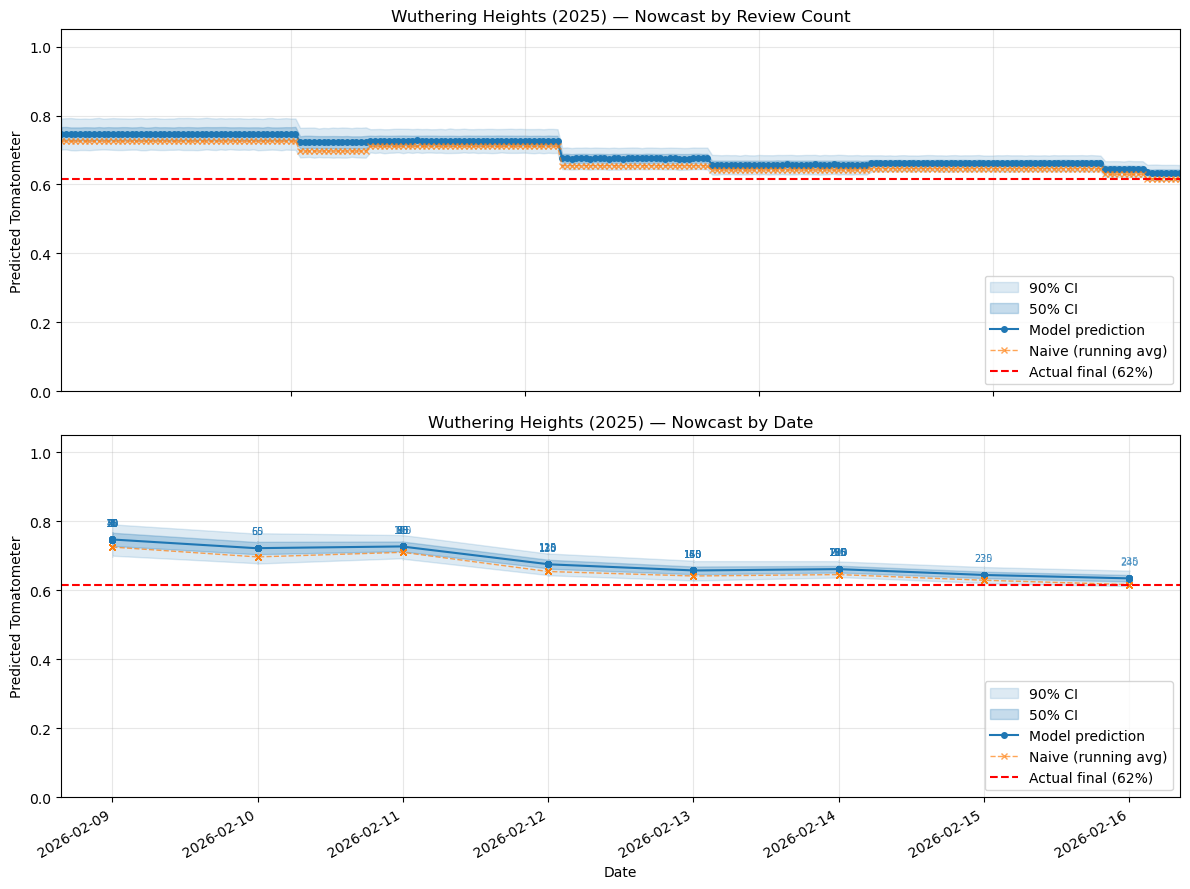

In [59]:
# ── Wuthering Heights: prediction timeline charts ─────────
fig, axes = plt.subplots(2, 1, figsize=(12, 9), sharex=False)

# --- Plot 1: by number of reviews ---
ax = axes[0]
ax.fill_between(tl["reviews_seen"], tl["p5"], tl["p95"],
                alpha=0.15, color="C0", label="90% CI")
ax.fill_between(tl["reviews_seen"], tl["p25"], tl["p75"],
                alpha=0.25, color="C0", label="50% CI")
ax.plot(tl["reviews_seen"], tl["predicted_T"], "o-", color="C0",
        markersize=4, linewidth=1.5, label="Model prediction")
ax.plot(tl["reviews_seen"], tl["current_T"], "x--", color="C1",
        markersize=4, linewidth=1, alpha=0.7, label="Naive (running avg)")
ax.axhline(y=actual_T, color="red", linestyle="--", linewidth=1.5,
           label=f"Actual final ({actual_T:.0%})")
ax.set_xlabel("Reviews Seen")
ax.set_ylabel("Predicted Tomatometer")
ax.set_title("Wuthering Heights (2025) — Nowcast by Review Count")
ax.set_xlim(1, total_n)
ax.set_ylim(0, 1.05)
ax.legend(loc="lower right")
ax.grid(True, alpha=0.3)

# --- Plot 2: by date ---
ax2 = axes[1]
dates = pd.to_datetime(tl["date"])
ax2.fill_between(dates, tl["p5"], tl["p95"],
                 alpha=0.15, color="C0", label="90% CI")
ax2.fill_between(dates, tl["p25"], tl["p75"],
                 alpha=0.25, color="C0", label="50% CI")
ax2.plot(dates, tl["predicted_T"], "o-", color="C0",
         markersize=4, linewidth=1.5, label="Model prediction")
ax2.plot(dates, tl["current_T"], "x--", color="C1",
         markersize=4, linewidth=1, alpha=0.7, label="Naive (running avg)")
ax2.axhline(y=actual_T, color="red", linestyle="--", linewidth=1.5,
            label=f"Actual final ({actual_T:.0%})")

# Annotate review count on date axis
for _, row in tl.iterrows():
    n = int(row["reviews_seen"])
    if n <= 5 or n % 5 == 0 or n == total_n:
        ax2.annotate(f"{n}", (pd.to_datetime(row["date"]), row["predicted_T"]),
                     textcoords="offset points", xytext=(0, 10),
                     fontsize=7, ha="center", color="C0", alpha=0.7)

ax2.set_xlabel("Date")
ax2.set_ylabel("Predicted Tomatometer")
ax2.set_title("Wuthering Heights (2025) — Nowcast by Date")
ax2.set_ylim(0, 1.05)
ax2.legend(loc="lower right")
ax2.grid(True, alpha=0.3)
fig.autofmt_xdate(rotation=30)

plt.tight_layout()
plt.show()

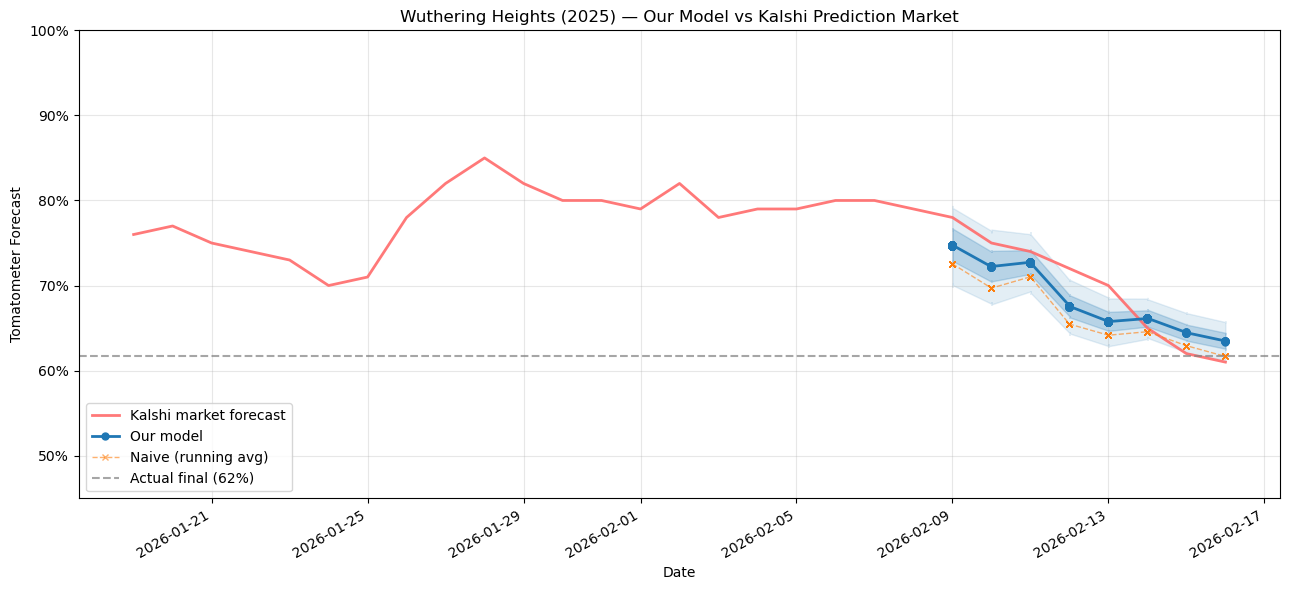

In [62]:
# ── Comparison: Model vs Kalshi prediction market ─────────
# Kalshi data eyeballed from screenshot — edit if you have exact values.
# Format: (date_str, forecast_value_in_pct)
kalshi_raw = [
    ("2026-01-19", 76), ("2026-01-20", 77), ("2026-01-21", 75),
    ("2026-01-22", 74), ("2026-01-23", 73), ("2026-01-24", 70),
    ("2026-01-25", 71), ("2026-01-26", 78), ("2026-01-27", 82),
    ("2026-01-28", 85), ("2026-01-29", 82), ("2026-01-30", 80),
    ("2026-01-31", 80), ("2026-02-01", 79), ("2026-02-02", 82),
    ("2026-02-03", 78), ("2026-02-04", 79), ("2026-02-05", 79),
    ("2026-02-06", 80), ("2026-02-07", 80), ("2026-02-08", 79),
    ("2026-02-09", 78), ("2026-02-10", 75), ("2026-02-11", 74),
    ("2026-02-12", 72), ("2026-02-13", 70), ("2026-02-14", 65),
    ("2026-02-15", 62), ("2026-02-16", 61),
]

kalshi = pd.DataFrame(kalshi_raw, columns=["date", "forecast"])
kalshi["date"] = pd.to_datetime(kalshi["date"])
kalshi["forecast_pct"] = kalshi["forecast"] / 100.0

model_dates = pd.to_datetime(tl["date"])

fig, ax = plt.subplots(figsize=(13, 6))

# Kalshi market line
ax.plot(kalshi["date"], kalshi["forecast_pct"], "-", color="#ff6b6b",
        linewidth=2, label="Kalshi market forecast", alpha=0.9)

# Model predictions with CI
ax.fill_between(model_dates, tl["p5"], tl["p95"],
                alpha=0.12, color="C0")
ax.fill_between(model_dates, tl["p25"], tl["p75"],
                alpha=0.22, color="C0")
ax.plot(model_dates, tl["predicted_T"], "o-", color="C0",
        markersize=5, linewidth=2, label="Our model", zorder=5)

# Naive running average
ax.plot(model_dates, tl["current_T"], "x--", color="C1",
        markersize=4, linewidth=1, alpha=0.6, label="Naive (running avg)")

# Actual final
ax.axhline(y=actual_T, color="gray", linestyle="--", linewidth=1.5,
           label=f"Actual final ({actual_T:.0%})", alpha=0.7)

ax.set_xlabel("Date")
ax.set_ylabel("Tomatometer Forecast")
ax.set_title("Wuthering Heights (2025) — Our Model vs Kalshi Prediction Market")
ax.set_ylim(0.45, 1.0)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
ax.legend(loc="lower left")
ax.grid(True, alpha=0.3)
fig.autofmt_xdate(rotation=30)
plt.tight_layout()
plt.show()